### Project Title: Predicting Student Final Exam Scores Using Regression

#### Prepared By:
- Name: Abhishek Sahu
- Domain: Data Science
- ID : CT_CSI_DS_5981

#### Project Overview:
- This project aims to build a regression model that can predict a student’s final exam score (G3) based on various academic, demographic, and behavioral factors. Using the Student Performance dataset, we explore the impact of features like study time, past scores, absences, and family background on academic outcomes.
- By leveraging exploratory data analysis (EDA), feature engineering, model building, and advanced evaluation techniques, the goal is to uncover key factors influencing academic performance and build a model that enables early identification of students at risk—allowing timely educational support and interventions.

#### Objectives:
- Understand feature relationships through exploring data distributions, correlations, and outliers through visual EDA
- Preprocess data: handle missing values, encode categorical features, normalize where needed
- Train and evaluate regression models to predict G3 (final grade)
- Interpret model performance and feature importance using RMSE, MAE, and R² Score
- Tune models using GridSearchCV and RandomizedSearchCV for optimal performance
- Visualize results: residuals, predictions, learning curves, and error distributions
- Test robustness with multiple train-test splits

#### Key Features Used:
| Category           | Features                                                                  |
| ------------------ | ------------------------------------------------------------------------- |
| Demographics       | `sex`, `age`, `address`, `famsize`, `Pstatus`                             |
| Parental Education | `Medu` (Mother), `Fedu` (Father)                                          |
| Parental Job       | `Mjob`, `Fjob`                                                            |
| Study Info         | `studytime`, `failures`, `schoolsup`, `famsup`, `paid`, `activities`      |
| Lifestyle          | `goout`, `Dalc` (weekday alcohol), `Walc` (weekend), `health`, `absences` |
| Grades             | `G1`, `G2`, `G3` (First, Second, Final period grades)                     |

#### Methods & Tools:
- Languages & Libraries: Python, Pandas, NumPy, Seaborn, Matplotlib, Scikit-learn
- Regression Techniques: Linear Regression, Ridge, Random Forest, KNN, SVR, XGBoost, etc.
- Evaluation Metrics: RMSE, MAE, R² Score
- Tuning Methods: GridSearchCV, RandomizedSearchCV
- Model Validation: Learning curves, cross-validation, robustness checks

#### Expected Outcomes:
- A regression model with high predictive accuracy for final exam scores
- Identify key factors affecting student performance like G1, G2, study time, and absences
- Clear visual and statistical analysis that aids interpretability
- Offer insights that can support educational decision-making and student performance tracking

### Dataset Metadata

| **Property**            | **Details**                                                 |
| ----------------------- | ----------------------------------------------------------- |
| **Dataset Name**        | Student Performance Dataset (Math)             |
| **Files**               | `student-mat.csv`                        |
| **Source**              | UCI Machine Learning Repository / Kaggle                    |
| **Number of Instances** | 395 (Math)                               |
| **Number of Features**  | 33 (including target `G3`)                                  |
| **Feature Types**       | Mixed – numeric, binary, and categorical                    |
| **Target Variable**     | `G3` (final exam score)                                     |
| **Prediction Type**     | Regression                                                  |
| **Missing Values**      | None (datasets are clean and complete)                      |
| **Language Courses**    | Math (student-mat)               |
| **Ideal Use Case**      | Predicting academic performance using regression techniques |


### Importing necessary libraries

In [1]:
# Importing necessary libraries for data manipulation and visualization
import numpy as np
import pandas as pd
from sklearn import metrics
from math import sqrt

# Importing visualization libraries and setting inline display for plots
from matplotlib import pyplot as plt
%matplotlib inline
from matplotlib.colors import ListedColormap

# Setting Seaborn and Matplotlib styles for better visualization
import seaborn as sns
sns.set()
plt.style.use('ggplot')
%matplotlib inline

# Importing functions for train/test split and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Importing functions for hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score

# Importing machine learning models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Importing additional metrics for model evaluation
from sklearn.metrics import confusion_matrix, mean_squared_error, r2_score, roc_auc_score, roc_curve, classification_report

# Importing XGBoost library
import os
from xgboost import XGBClassifier

# Importing additional preprocessing and pipeline utilities
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder

# Importing additional regression models and ensemble methods
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Ignoring warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

In [86]:
# Assuming you have the datasets loaded into 'student-mat.csv' and 'student-por.csv'
df = pd.read_csv(r"C:\Users\sahua\OneDrive\Desktop\Data_science\Celebal Technology\Project\student-mat.csv", sep=';')

### Data Profiling

In [27]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [28]:
df.tail()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


In [151]:
# Showing No. of Rows and Columns of Dataset
df.shape

(395, 33)

In [152]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [153]:
# Showing information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [154]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [155]:
df.nunique()

school         2
sex            2
age            8
address        2
famsize        2
Pstatus        2
Medu           5
Fedu           5
Mjob           5
Fjob           5
reason         4
guardian       3
traveltime     4
studytime      4
failures       4
schoolsup      2
famsup         2
paid           2
activities     2
nursery        2
higher         2
internet       2
romantic       2
famrel         5
freetime       5
goout          5
Dalc           5
Walc           5
health         5
absences      34
G1            17
G2            17
G3            18
dtype: int64

In [156]:
# Checking Data Types
df.dtypes

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

In [157]:
df.dtypes[df.dtypes != 'object']

age           int64
Medu          int64
Fedu          int64
traveltime    int64
studytime     int64
failures      int64
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

### Data Preprocessing

In [29]:
#find the object,int,float value
t = (df.dtypes == 'object')
object_cols = list(t[t].index)
print("Categorical variables:")
print(object_cols)
print('-'*50)

t = (df.dtypes == 'int64')
num_cols = list(t[t].index)
print("Integer variables:")
print(num_cols)
print('-'*50)

t = (df.dtypes == 'float64')
num_cols = list(t[t].index)
print("Float variables:")
print('-'*50)

Categorical variables:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
--------------------------------------------------
Integer variables:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
--------------------------------------------------
Float variables:
--------------------------------------------------


In [5]:
#find the missing value
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [87]:
# List of categorical variables
categorical_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
                    'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
                    'nursery', 'higher', 'internet', 'romantic']

# Analyzing categorical variables
for col in categorical_cols:
    print(df[col].value_counts())


school
GP    349
MS     46
Name: count, dtype: int64
sex
F    208
M    187
Name: count, dtype: int64
address
U    307
R     88
Name: count, dtype: int64
famsize
GT3    281
LE3    114
Name: count, dtype: int64
Pstatus
T    354
A     41
Name: count, dtype: int64
Mjob
other       141
services    103
at_home      59
teacher      58
health       34
Name: count, dtype: int64
Fjob
other       217
services    111
teacher      29
at_home      20
health       18
Name: count, dtype: int64
reason
course        145
home          109
reputation    105
other          36
Name: count, dtype: int64
guardian
mother    273
father     90
other      32
Name: count, dtype: int64
schoolsup
no     344
yes     51
Name: count, dtype: int64
famsup
yes    242
no     153
Name: count, dtype: int64
paid
no     214
yes    181
Name: count, dtype: int64
activities
yes    201
no     194
Name: count, dtype: int64
nursery
yes    314
no      81
Name: count, dtype: int64
higher
yes    375
no      20
Name: count, dtype: int64

In [88]:
# List of numerical variables
numerical_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
                  'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

# Summary statistics of numerical variables
print(df[numerical_cols].describe())


              age        Medu        Fedu  traveltime   studytime    failures  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean    16.696203    2.749367    2.521519    1.448101    2.035443    0.334177   
std      1.276043    1.094735    1.088201    0.697505    0.839240    0.743651   
min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
25%     16.000000    2.000000    2.000000    1.000000    1.000000    0.000000   
50%     17.000000    3.000000    2.000000    1.000000    2.000000    0.000000   
75%     18.000000    4.000000    3.000000    2.000000    2.000000    0.000000   
max     22.000000    4.000000    4.000000    4.000000    4.000000    3.000000   

           famrel    freetime       goout        Dalc        Walc      health  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean     3.944304    3.235443    3.108861    1.481013    2.291139    3.554430   
std      0.896659    0.9988

In [89]:
# Use the target variable
target_col = 'G3'
# Confirm column names and proceed
print("Columns in the dataset after handling target variable:", df.columns)
print("Target column:", target_col)

Columns in the dataset after handling target variable: Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')
Target column: G3


count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


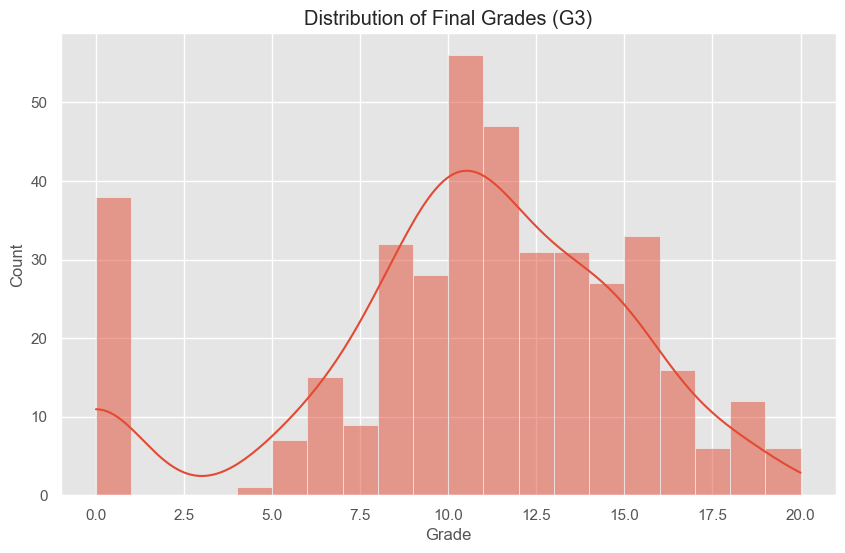

In [90]:
# Choose the appropriate column for the target variable
target_col = 'G3'

# Ensure 'G3' exists in the DataFrame
if target_col in df.columns:
    print(df[target_col].describe())

    # Visualize the distribution of the selected final grade
    plt.figure(figsize=(10, 6))
    sns.histplot(df[target_col], bins=20, kde=True)
    plt.title('Distribution of Final Grades (G3)')
    plt.xlabel('Grade')
    plt.ylabel('Count')
    plt.show()
else:
    print(f"Column '{target_col}' does not exist in the DataFrame.")


               G3      G3_log
count  395.000000  395.000000
mean    10.415190    2.252858
std      4.581443    0.779548
min      0.000000    0.000000
25%      8.000000    2.197225
50%     11.000000    2.484907
75%     14.000000    2.708050
max     20.000000    3.044522


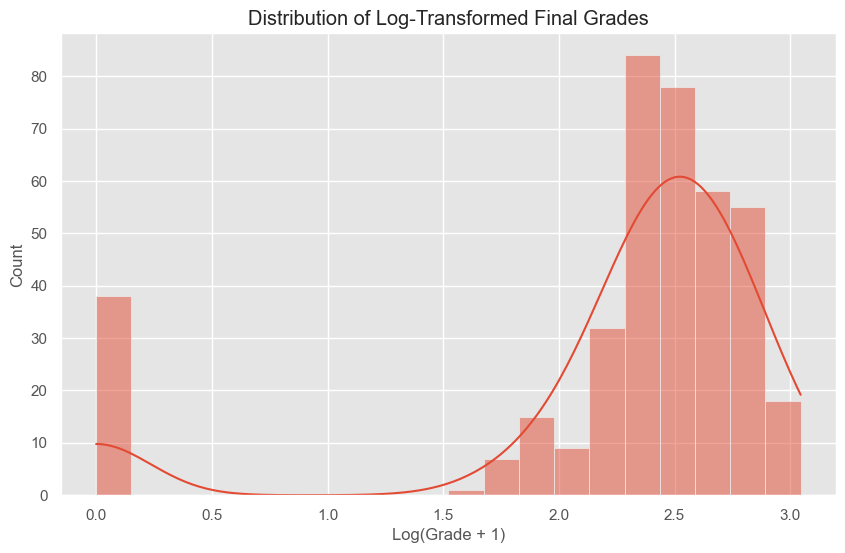

In [91]:
# Check if target_col exists in the DataFrame
if target_col in df.columns:
    # Apply log transformation
    # Add a small constant (e.g., 1) to avoid log(0) issue
    df[target_col + '_log'] = np.log(df[target_col] + 1)

    # Check the new column
    print(df[[target_col, target_col + '_log']].describe())

    # Visualize the distribution of the log-transformed final grade
    plt.figure(figsize=(10, 6))
    sns.histplot(df[target_col + '_log'], bins=20, kde=True)
    plt.title('Distribution of Log-Transformed Final Grades')
    plt.xlabel('Log(Grade + 1)')
    plt.ylabel('Count')
    plt.show()
else:
    print(f"Column '{target_col}' does not exist in the DataFrame.")

In [92]:
# Outlier detection using IQR method
Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[target_col] < lower_bound) | (df[target_col] > upper_bound)]
cleaned_data = df[(df[target_col] >= lower_bound) & (df[target_col] <= upper_bound)]

print(f'Number of outliers: {outliers.shape[0]}')


Number of outliers: 0


Number of outliers in G3: 0


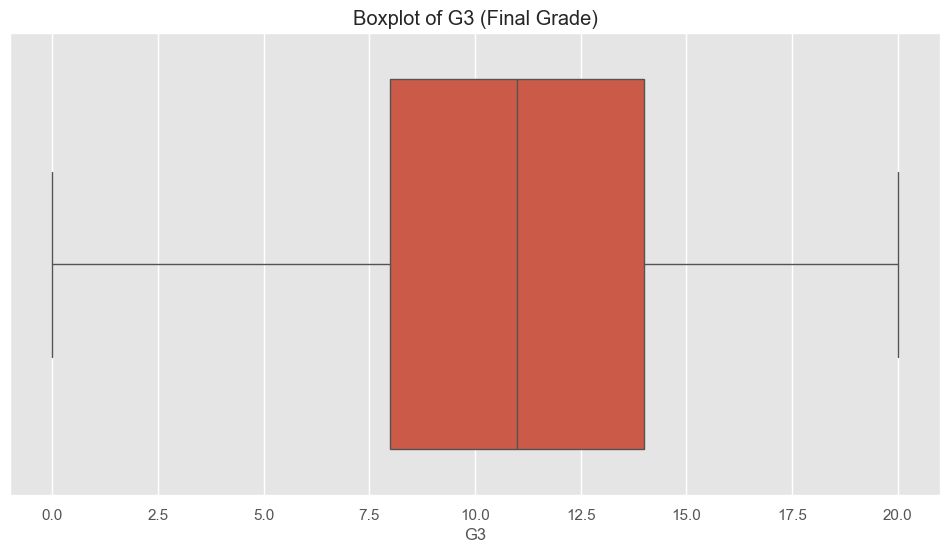

Original data shape: (395, 34)
Cleaned data shape: (395, 34)


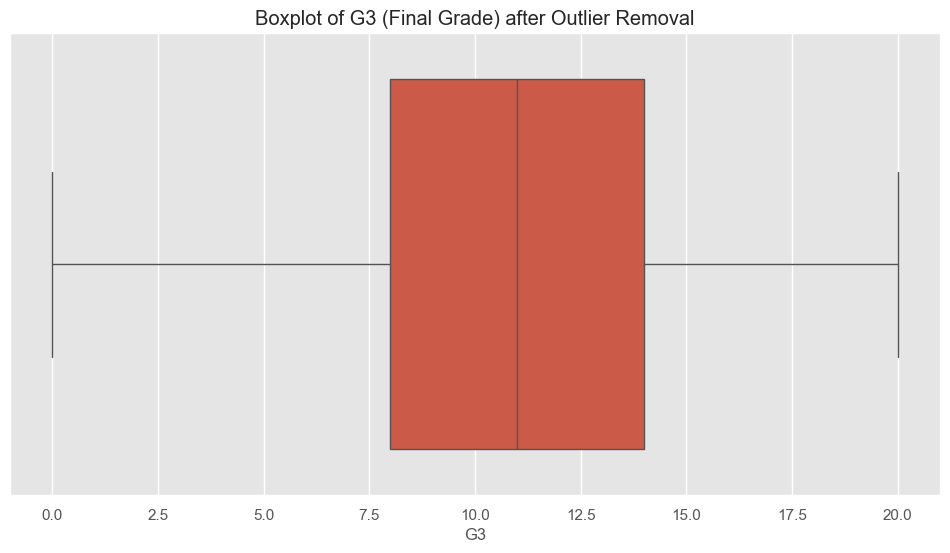

In [93]:
# Function to detect outliers using IQR
def detect_outliers(df, target_col):
    Q1 = df[target_col].quantile(0.25)
    Q3 = df[target_col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[target_col] < lower_bound) | (df[target_col] > upper_bound)]
    return outliers

# Function to remove outliers using IQR
def remove_outliers(df, target_col):
    Q1 = df[target_col].quantile(0.25)
    Q3 = df[target_col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned = df[(df[target_col] >= lower_bound) & (df[target_col] <= upper_bound)]
    return df_cleaned

# Identify and visualize outliers in the target variable 'G3'
outliers_G3 = detect_outliers(df, target_col)
print(f'Number of outliers in {target_col}: {outliers_G3.shape[0]}')

plt.figure(figsize=(12, 6))
sns.boxplot(x=df[target_col])
plt.title(f'Boxplot of {target_col} (Final Grade)')
plt.show()

# Remove outliers in 'G3'
cleaned_data = remove_outliers(df, target_col)

# Verify removal of outliers
print(f'Original data shape: {df.shape}')
print(f'Cleaned data shape: {df.shape}')

plt.figure(figsize=(12, 6))
sns.boxplot(x=df[target_col])
plt.title(f'Boxplot of {target_col} (Final Grade) after Outlier Removal')
plt.show()


In [94]:
# Checking for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 Series([], dtype: int64)


In [95]:
# For each column, print the unique values
for col in df.columns:
    print(f"{col}:")
    print(df[col].unique())
    print("-" * 40)

school:
['GP' 'MS']
----------------------------------------
sex:
['F' 'M']
----------------------------------------
age:
[18 17 15 16 19 22 20 21]
----------------------------------------
address:
['U' 'R']
----------------------------------------
famsize:
['GT3' 'LE3']
----------------------------------------
Pstatus:
['A' 'T']
----------------------------------------
Medu:
[4 1 3 2 0]
----------------------------------------
Fedu:
[4 1 2 3 0]
----------------------------------------
Mjob:
['at_home' 'health' 'other' 'services' 'teacher']
----------------------------------------
Fjob:
['teacher' 'other' 'services' 'health' 'at_home']
----------------------------------------
reason:
['course' 'other' 'home' 'reputation']
----------------------------------------
guardian:
['mother' 'father' 'other']
----------------------------------------
traveltime:
[2 1 3 4]
----------------------------------------
studytime:
[2 3 1 4]
----------------------------------------
failures:
[0 3 2 1]
---

#### Feature Engineering

In [96]:
# Drop selected irrelevent columns from the dataset
cols_to_drop = ['school', 'guardian', 'reason', 'nursery']
df_cleaned = df.drop(columns=cols_to_drop)

# Check the new shape and preview
print("Shape after dropping columns:", df_cleaned.shape)
df_cleaned.head()

Shape after dropping columns: (395, 30)


,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,traveltime,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,G3_log
0,F,18,U,GT3,A,4,4,at_home,teacher,2,...,3,4,1,1,3,6,5,6,6,1.945910
1,F,17,U,GT3,T,1,1,at_home,other,1,...,3,3,1,1,3,4,5,5,6,1.945910
2,F,15,U,LE3,T,1,1,at_home,other,1,...,3,2,2,3,3,10,7,8,10,2.397895
3,F,15,U,GT3,T,4,2,health,services,1,...,2,2,1,1,5,2,15,14,15,2.772589
4,F,16,U,GT3,T,3,3,other,other,1,...,3,2,1,2,5,4,6,10,10,2.397895


In [97]:
# Creating a new feature 'ParentEdu' by combining mother's and father's education
df_cleaned['ParentEdu'] = df_cleaned['Medu'] + df_cleaned['Fedu']

In [98]:
# Creating a new feature 'FamilySize'
df_cleaned['FamilySize'] = df_cleaned['famsize'].apply(lambda x: 1 if x == 'LE3' else 2)
cols_to_drop = ['famsize']
df_cleaned = df_cleaned.drop(columns=cols_to_drop)
df_cleaned.head()

,sex,age,address,Pstatus,Medu,Fedu,Mjob,Fjob,traveltime,studytime,...,Dalc,Walc,health,absences,G1,G2,G3,G3_log,ParentEdu,FamilySize
0,F,18,U,A,4,4,at_home,teacher,2,2,...,1,1,3,6,5,6,6,1.945910,8,2
1,F,17,U,T,1,1,at_home,other,1,2,...,1,1,3,4,5,5,6,1.945910,2,2
2,F,15,U,T,1,1,at_home,other,1,2,...,2,3,3,10,7,8,10,2.397895,2,1
3,F,15,U,T,4,2,health,services,1,3,...,1,1,5,2,15,14,15,2.772589,6,2
4,F,16,U,T,3,3,other,other,1,2,...,1,2,5,4,6,10,10,2.397895,6,2


In [99]:
# Encoding binary categorical features to 0 and 1
binary_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'higher', 'internet', 'romantic', 'Pstatus']
for col in binary_cols:
    df_cleaned[col] = df_cleaned[col].map({'yes': 1, 'no': 0})
    df_cleaned[col] = df_cleaned[col].map({'T': 1, 'A': 0})


Skewness of 'absences': 3.67


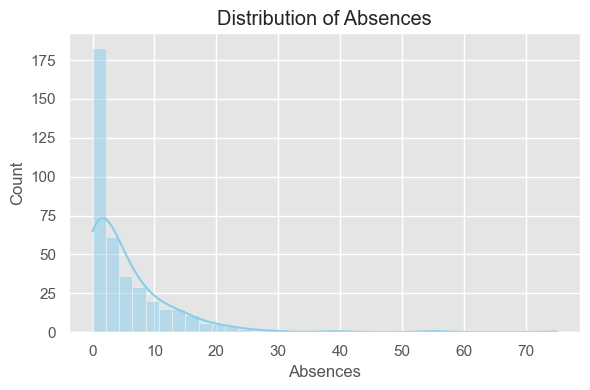

In [100]:
# Check skewness of 'absences'
skew_value = df_cleaned['absences'].skew()
print(f"Skewness of 'absences': {skew_value:.2f}")

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.histplot(df_cleaned['absences'], kde=True, color='skyblue')
plt.title("Distribution of Absences")
plt.xlabel("Absences")
plt.tight_layout()
plt.show()

In [101]:
# Log transformation of 'absences' to handle skewness
df_cleaned['log_absences'] = np.log1p(df_cleaned['absences'])
print("Skewness after log:", df_cleaned['log_absences'].skew())


Skewness after log: 0.07128935952936238


In [102]:
# Creating dummy variables for nominal categorical features
nominal_cols = ['Mjob', 'Fjob']
df_cleaned = pd.get_dummies(df_cleaned, columns=nominal_cols, drop_first=True)


In [103]:
# Creating a new feature 'HighFamRel' indicating high quality of family relationships
df_cleaned['HighFamRel'] = df_cleaned['famrel'].apply(lambda x: 1 if x >= 4 else 0)

In [104]:
# Display basic information about the dataset
print(df_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 39 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sex            395 non-null    object 
 1   age            395 non-null    int64  
 2   address        395 non-null    object 
 3   Pstatus        0 non-null      float64
 4   Medu           395 non-null    int64  
 5   Fedu           395 non-null    int64  
 6   traveltime     395 non-null    int64  
 7   studytime      395 non-null    int64  
 8   failures       395 non-null    int64  
 9   schoolsup      0 non-null      float64
 10  famsup         0 non-null      float64
 11  paid           0 non-null      float64
 12  activities     0 non-null      float64
 13  higher         0 non-null      float64
 14  internet       0 non-null      float64
 15  romantic       0 non-null      float64
 16  famrel         395 non-null    int64  
 17  freetime       395 non-null    int64  
 18  goout     

In [105]:
# Summary statistics for numerical variables
print(df_cleaned.describe())


              age  Pstatus        Medu        Fedu  traveltime   studytime  \
count  395.000000      0.0  395.000000  395.000000  395.000000  395.000000   
mean    16.696203      NaN    2.749367    2.521519    1.448101    2.035443   
std      1.276043      NaN    1.094735    1.088201    0.697505    0.839240   
min     15.000000      NaN    0.000000    0.000000    1.000000    1.000000   
25%     16.000000      NaN    2.000000    2.000000    1.000000    1.000000   
50%     17.000000      NaN    3.000000    2.000000    1.000000    2.000000   
75%     18.000000      NaN    4.000000    3.000000    2.000000    2.000000   
max     22.000000      NaN    4.000000    4.000000    4.000000    4.000000   

         failures  schoolsup  famsup  paid  ...      health    absences  \
count  395.000000        0.0     0.0   0.0  ...  395.000000  395.000000   
mean     0.334177        NaN     NaN   NaN  ...    3.554430    5.708861   
std      0.743651        NaN     NaN   NaN  ...    1.390303    8.003096 

In [106]:
# Print the column names of the DataFrame
print(df_cleaned.columns)


Index(['sex', 'age', 'address', 'Pstatus', 'Medu', 'Fedu', 'traveltime',
       'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'G3_log', 'ParentEdu',
       'FamilySize', 'log_absences', 'Mjob_health', 'Mjob_other',
       'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other',
       'Fjob_services', 'Fjob_teacher', 'HighFamRel'],
      dtype='object')


In [108]:
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# List of categorical columns (updated based on the provided column names)
categorical = ['sex', 'address', 'Pstatus', 'schoolsup', 'famsup', 'paid',
                    'activities', 'higher', 'internet', 'romantic',
                    'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher',
                    'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher',]

# Initialize the label encoder
encoder = LabelEncoder()

# Encode categorical columns
for col in categorical:
    if col in df_cleaned.columns:
        df_cleaned[col] = encoder.fit_transform(df_cleaned[col])
    else:
        print(f"Column '{col}' not found in the DataFrame.")


In [109]:
# Check for NaN values
print(df_cleaned.isna().sum())


sex              0
age              0
address          0
Pstatus          0
Medu             0
Fedu             0
traveltime       0
studytime        0
failures         0
schoolsup        0
famsup           0
paid             0
activities       0
higher           0
internet         0
romantic         0
famrel           0
freetime         0
goout            0
Dalc             0
Walc             0
health           0
absences         0
G1               0
G2               0
G3               0
G3_log           0
ParentEdu        0
FamilySize       0
log_absences     0
Mjob_health      0
Mjob_other       0
Mjob_services    0
Mjob_teacher     0
Fjob_health      0
Fjob_other       0
Fjob_services    0
Fjob_teacher     0
HighFamRel       0
dtype: int64


### Data Visualization

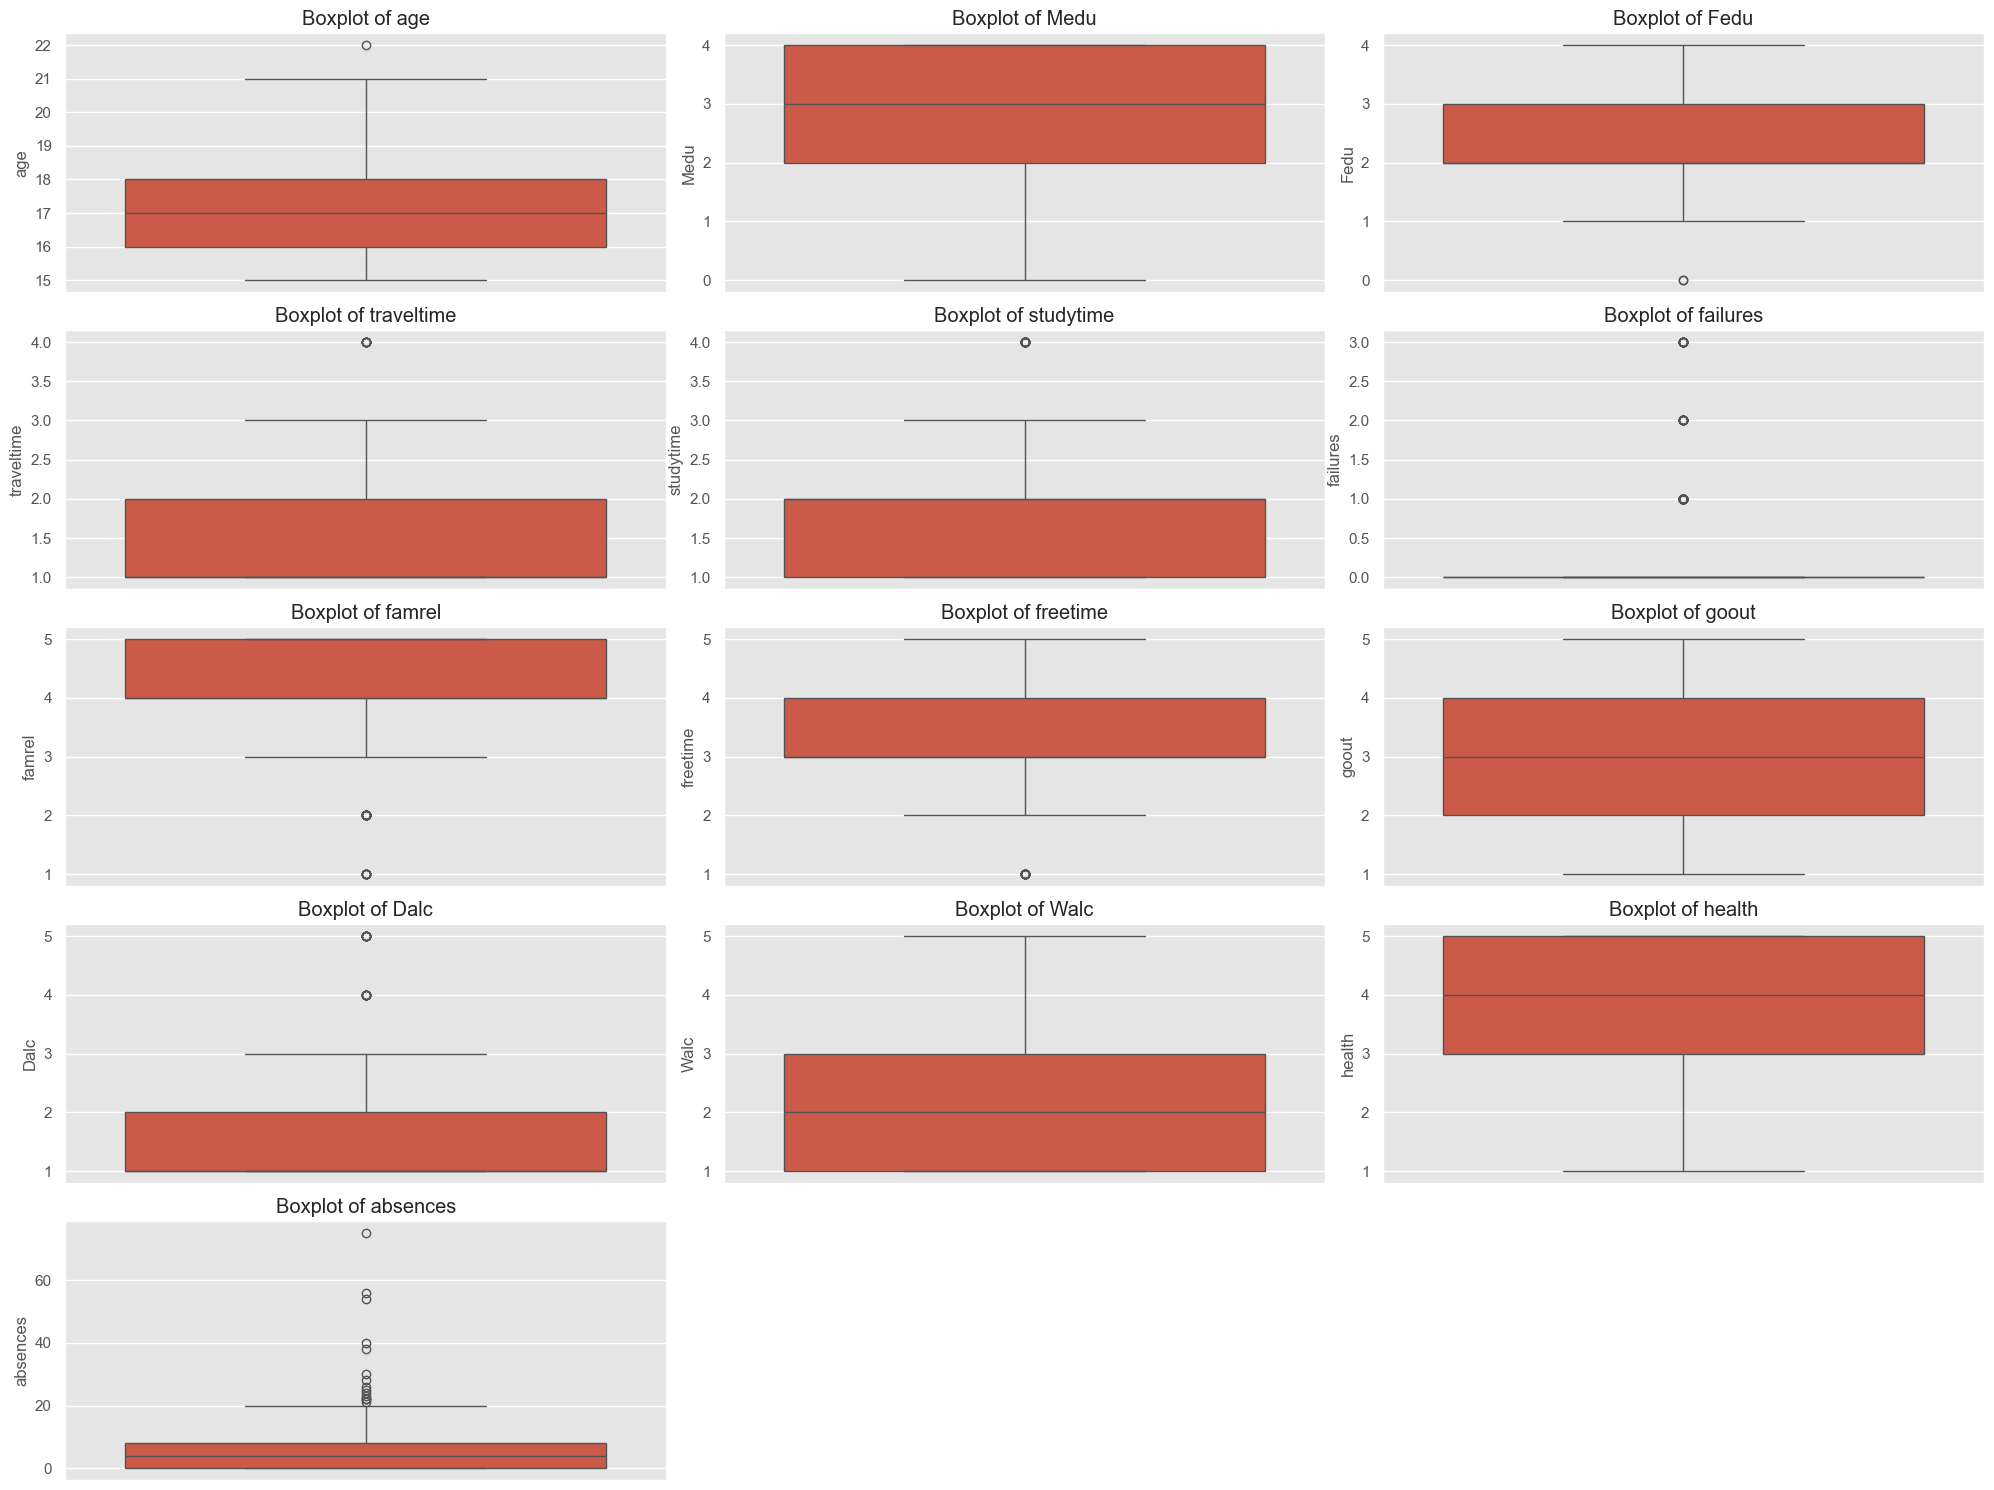

In [182]:
# Function to plot boxplots for numerical columns
def plot_boxplots(data, columns):
    plt.figure(figsize=(20, 15))
    for i, col in enumerate(columns, 1):
        plt.subplot(5, 3, i)
        sns.boxplot(y=data[col])
        plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

# Plot boxplots to visualize outliers
plot_boxplots(df_cleaned, numerical_cols)

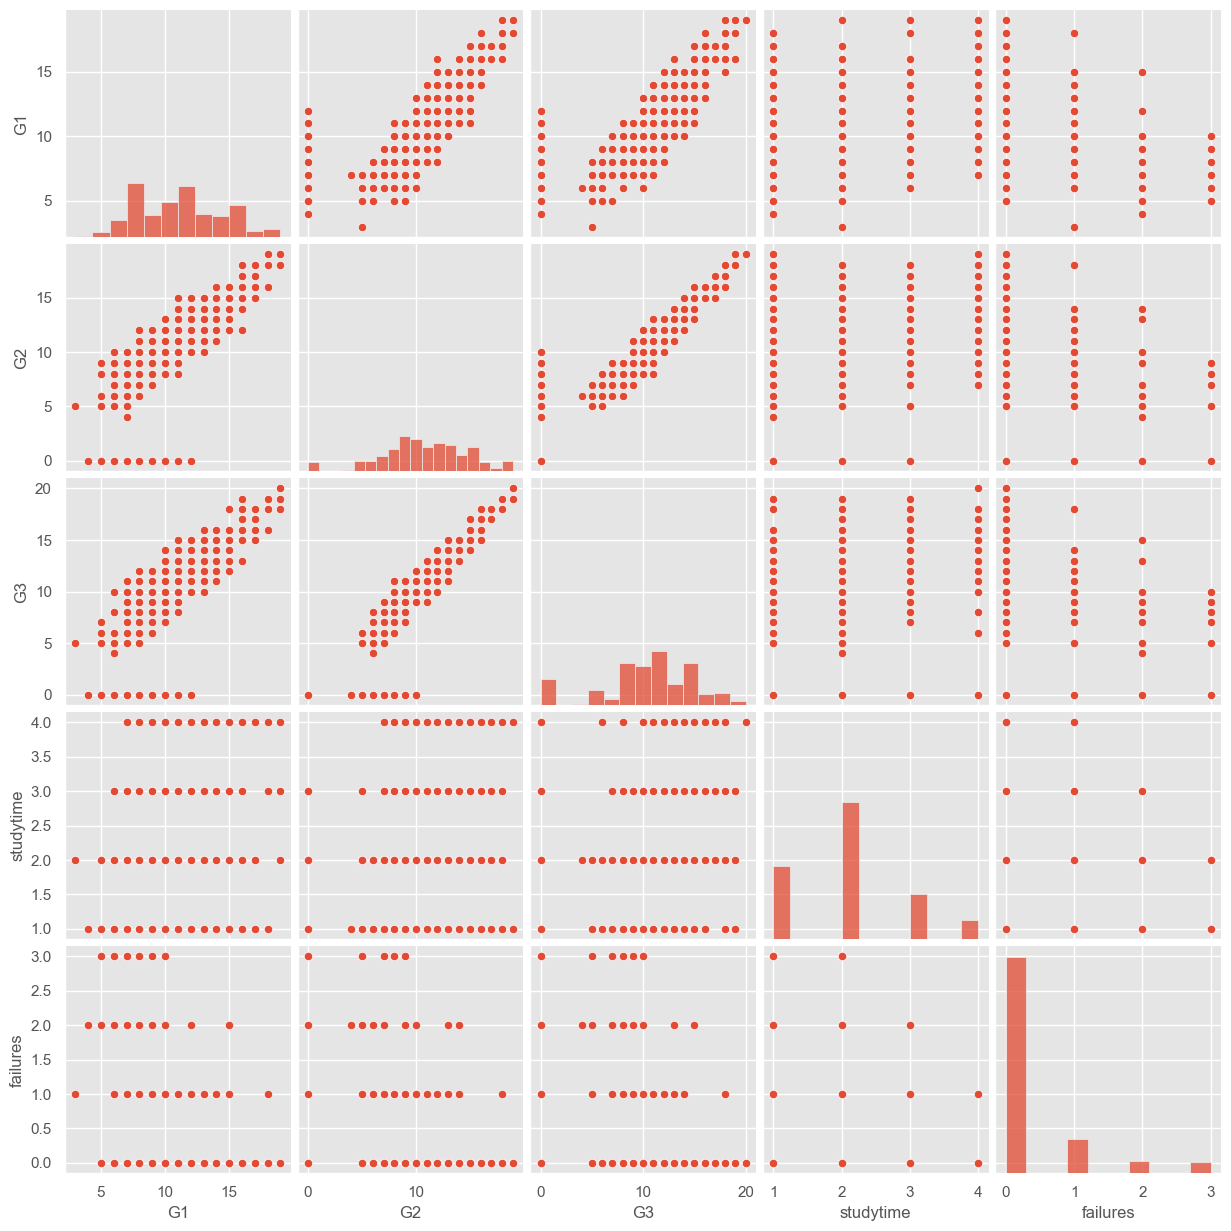

In [183]:
# Example: Visualizing relationships using scatter plots or heatmaps
sns.pairplot(df_cleaned[['G1', 'G2', 'G3', 'studytime', 'failures']])
plt.show()

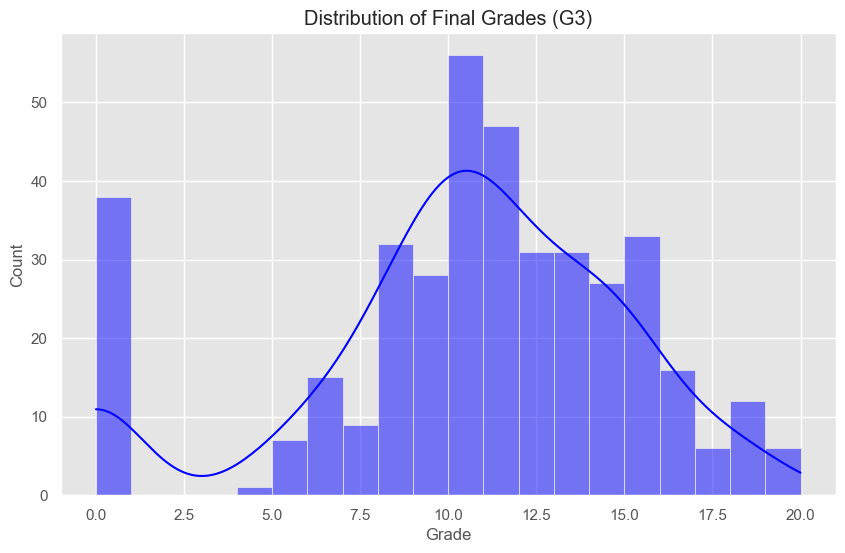

In [184]:
# Distribution of the target variable 'G3' (Final Grade)
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['G3'], bins=20, kde=True, color='blue')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.show()


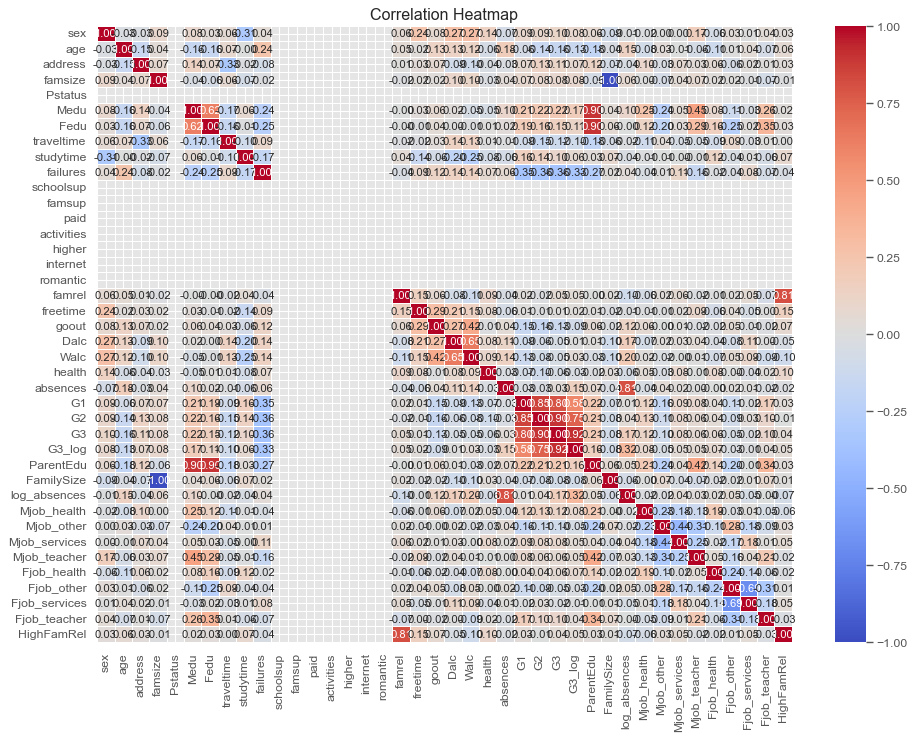

In [185]:
# Compute the correlation matrix
correlation_matrix = df_cleaned.corr()

# Adjust the figure size and dpi
plt.figure(figsize=(14, 10), dpi=80)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

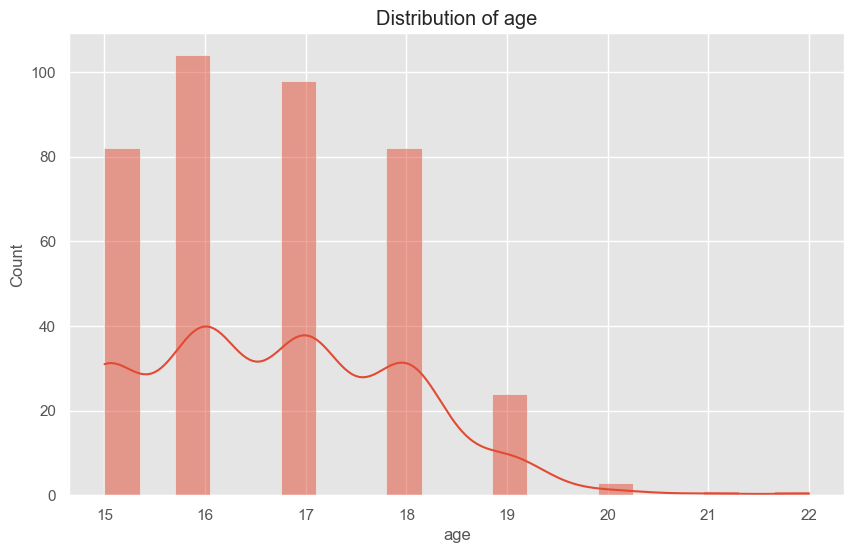

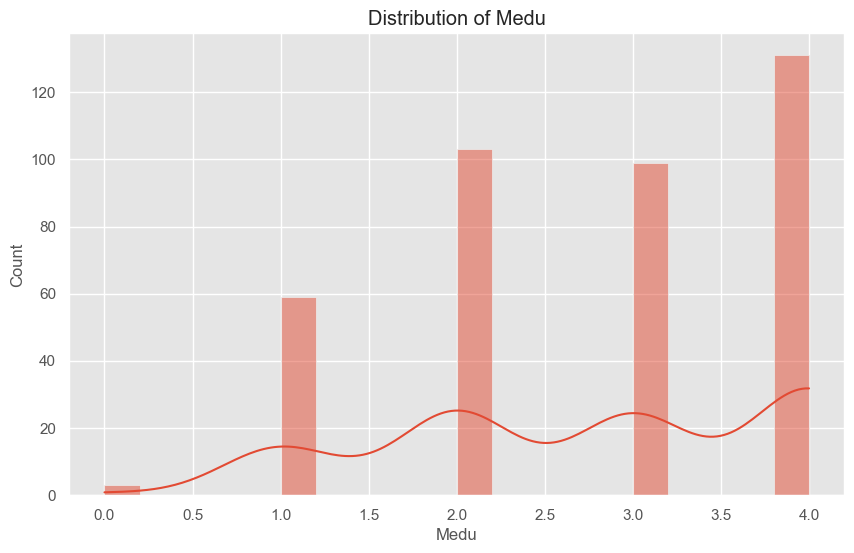

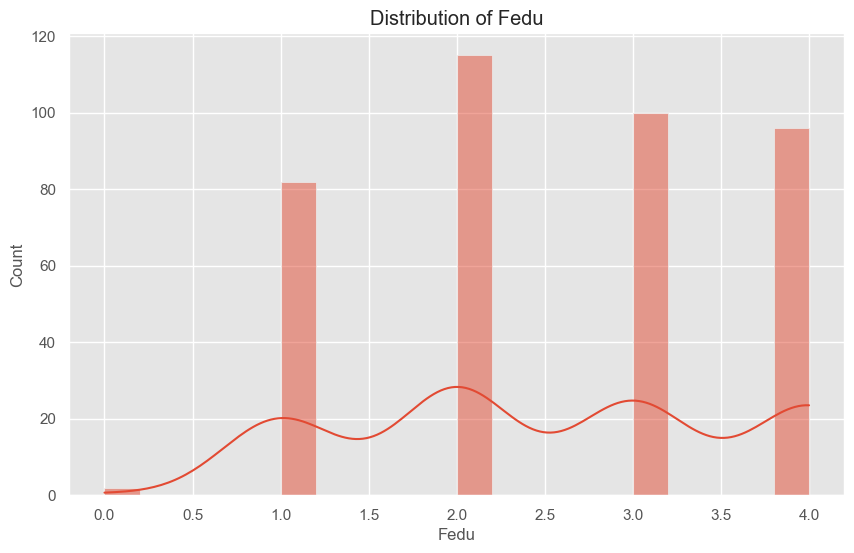

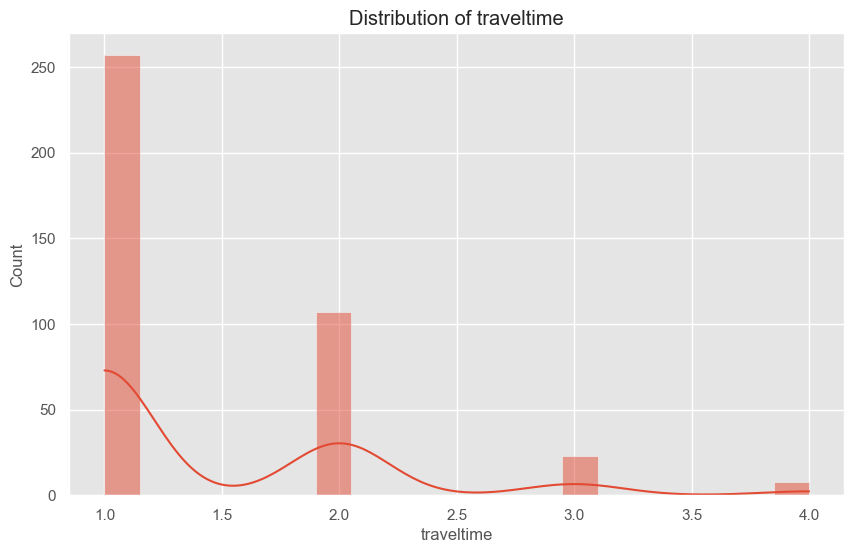

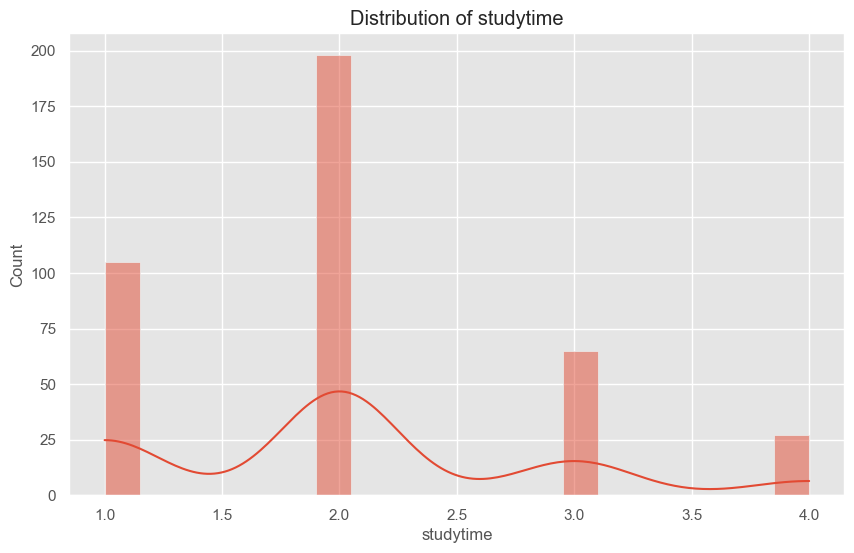

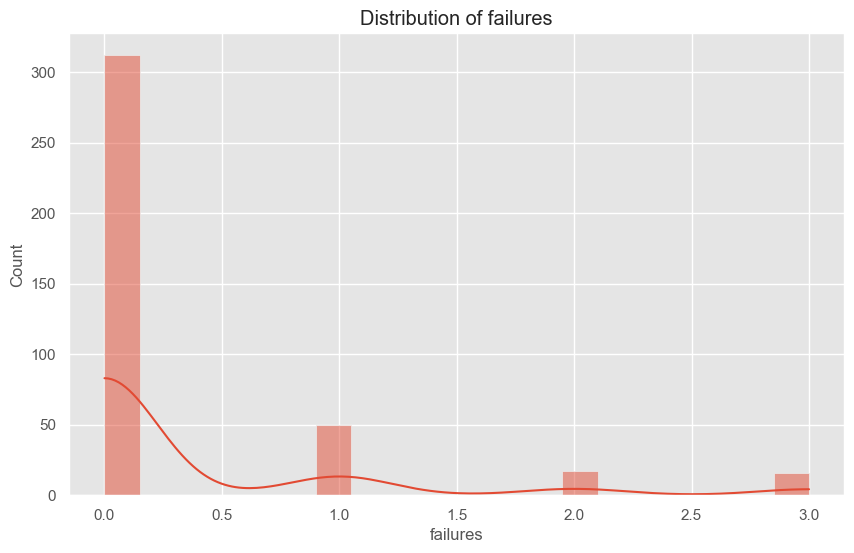

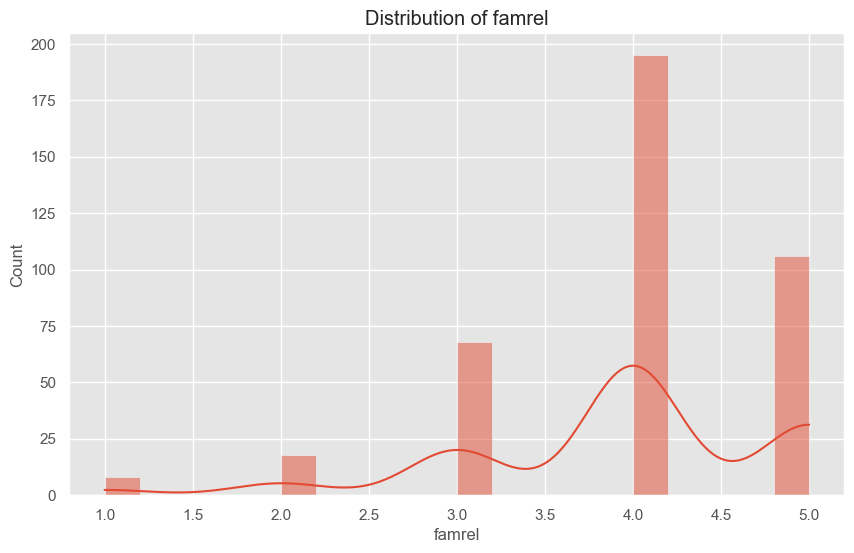

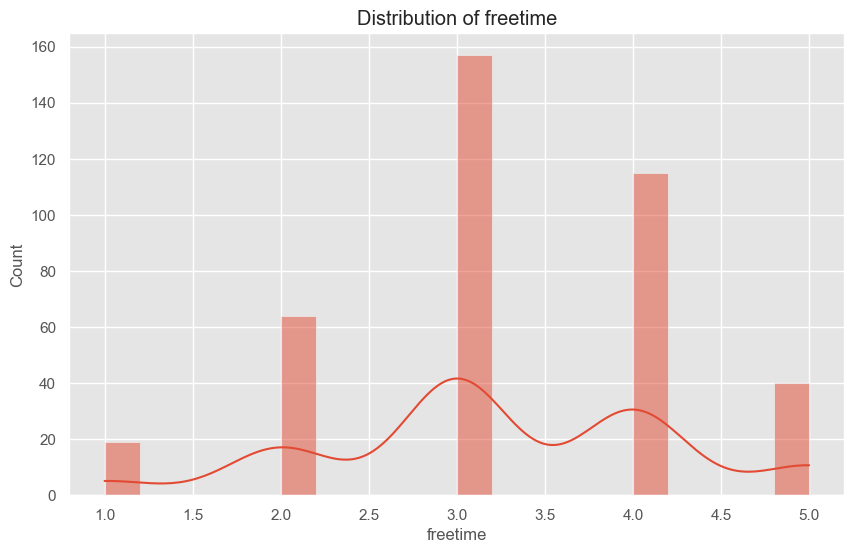

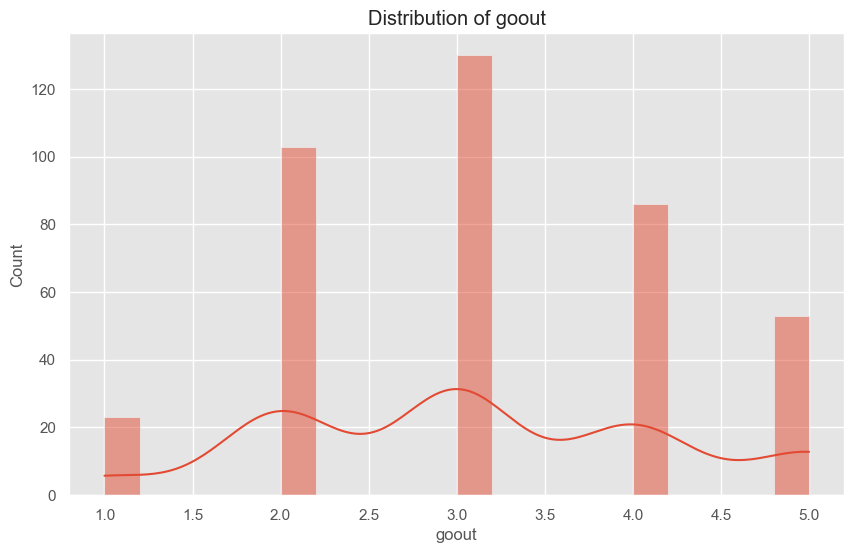

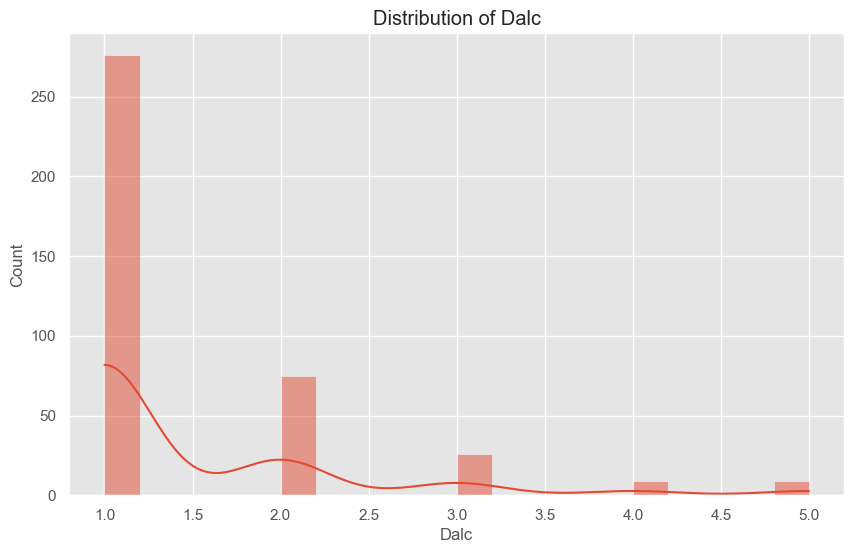

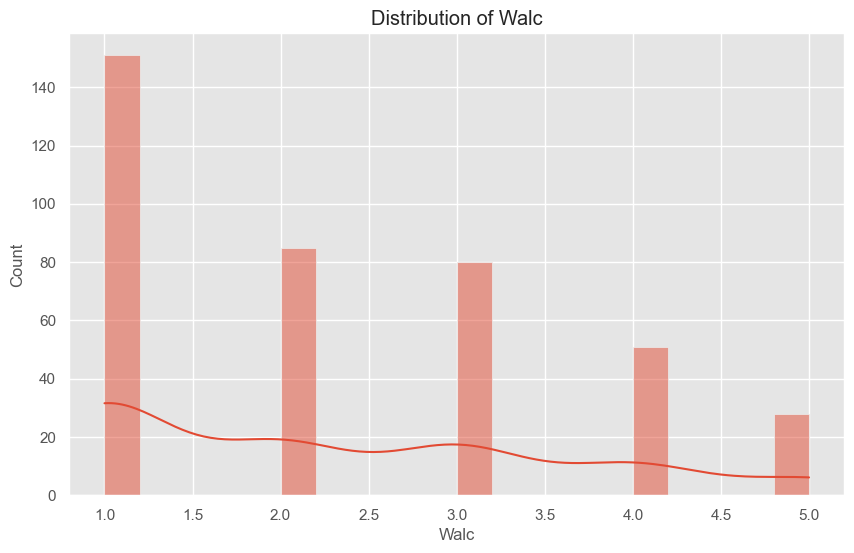

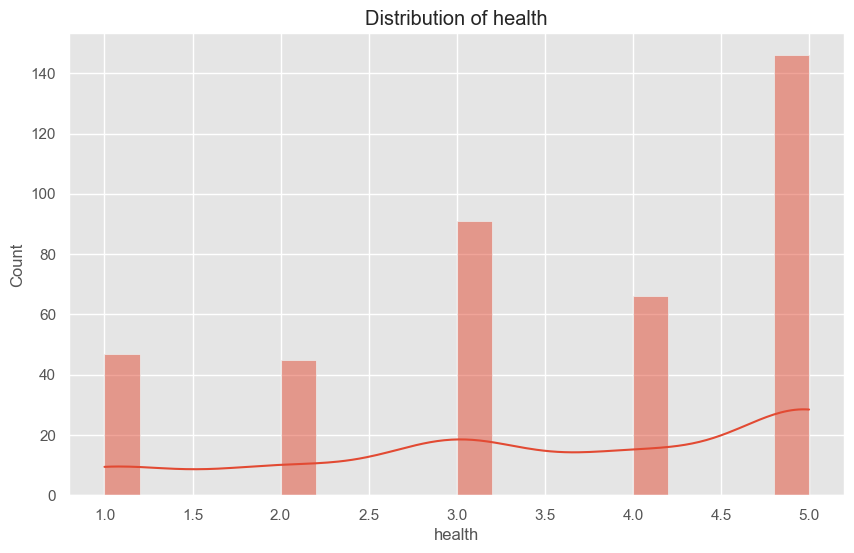

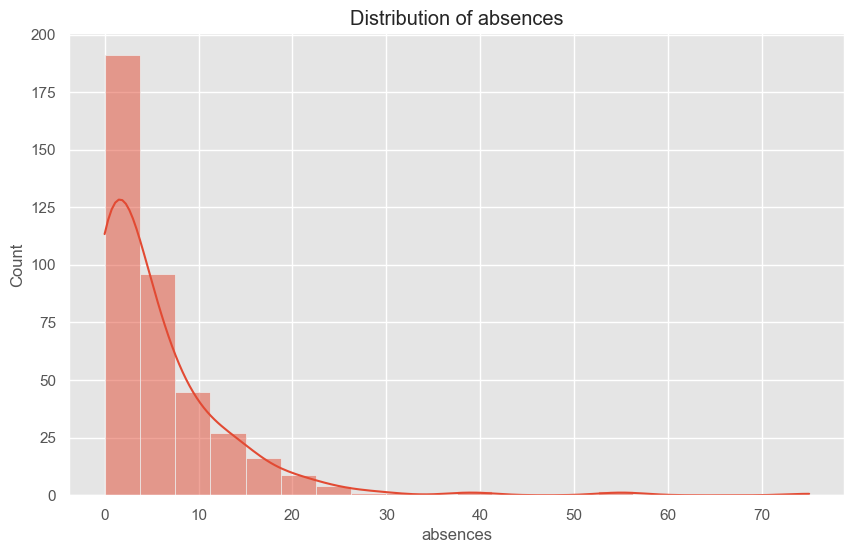

In [186]:
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_cleaned[col], bins=20, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

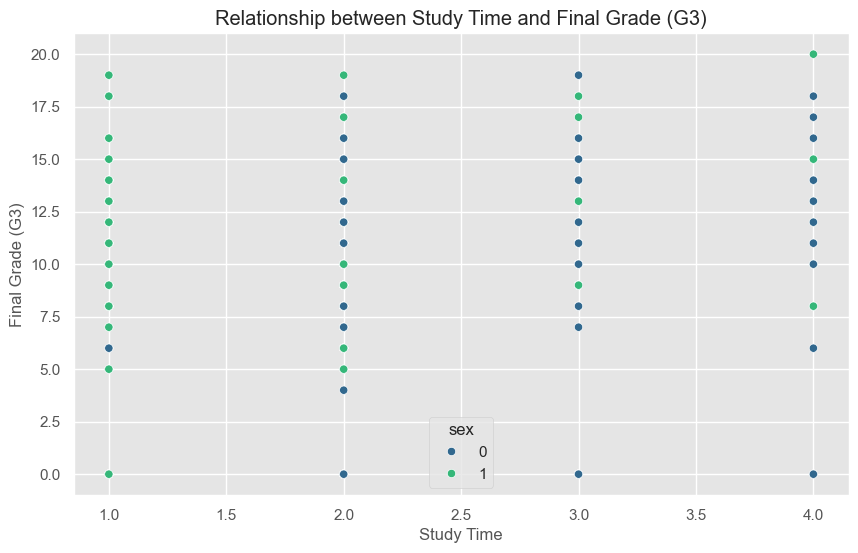

In [187]:
# Scatterplot to visualize the relationship between study time and final grade (G3)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='studytime', y='G3', data=df_cleaned, hue='sex', palette='viridis')
plt.title('Relationship between Study Time and Final Grade (G3)')
plt.xlabel('Study Time')
plt.ylabel('Final Grade (G3)')
plt.show()


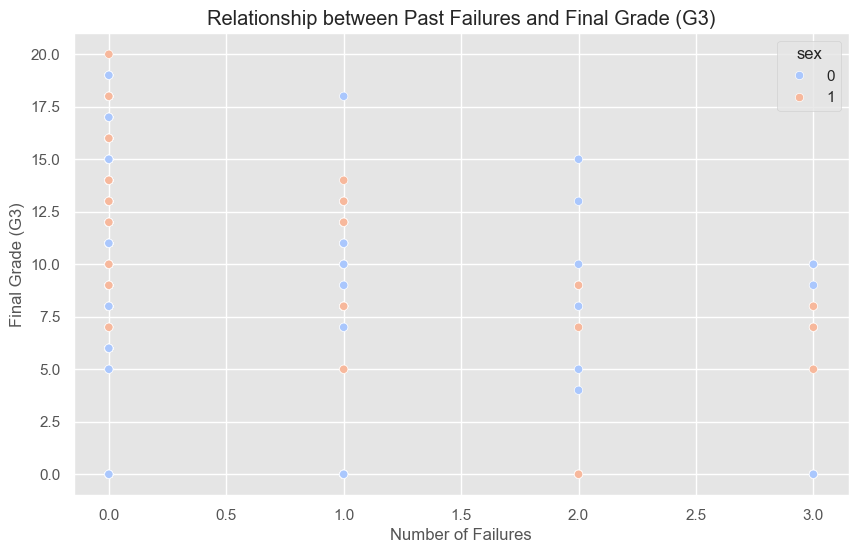

In [188]:
# Scatterplot to visualize the relationship between past failures and final grade (G3)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='failures', y='G3', data=df_cleaned, hue='sex', palette='coolwarm')
plt.title('Relationship between Past Failures and Final Grade (G3)')
plt.xlabel('Number of Failures')
plt.ylabel('Final Grade (G3)')
plt.show()


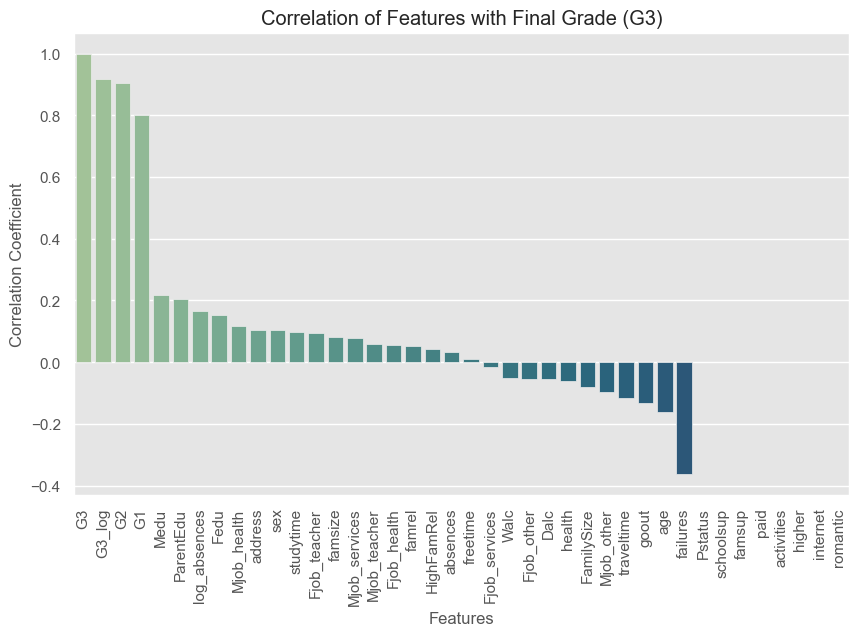

In [189]:
# Correlation of features with the target variable 'G3'
feature_correlation = df_cleaned.corr()['G3'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_correlation.index, y=feature_correlation.values, palette='crest')
plt.title('Correlation of Features with Final Grade (G3)')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=90)
plt.show()


### Normalizing the data for Model training

In [110]:
X = df_cleaned.drop(columns=['G1','G2','G3'])
y = df_cleaned['G3']

In [111]:
categorical_cols

['school',
 'sex',
 'address',
 'famsize',
 'Pstatus',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic']

In [112]:
print(X.columns)


Index(['sex', 'age', 'address', 'Pstatus', 'Medu', 'Fedu', 'traveltime',
       'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G3_log', 'ParentEdu', 'FamilySize',
       'log_absences', 'Mjob_health', 'Mjob_other', 'Mjob_services',
       'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services',
       'Fjob_teacher', 'HighFamRel'],
      dtype='object')


In [113]:
missing_cols = [col for col in categorical_cols if col not in X.columns]
print("Missing columns:", missing_cols)

Missing columns: ['school', 'famsize', 'Mjob', 'Fjob', 'reason', 'guardian', 'nursery']


In [114]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Define categorical columns
categorical_cols = ['sex', 'address', 'Pstatus','schoolsup', 'famsup', 'paid', 'activities','higher', 'internet', 'romantic']

# Initialize the OneHotEncoder
onehot_encoder = OneHotEncoder(drop='first', sparse_output=False)

# Fit and transform the categorical data
X_encoded = onehot_encoder.fit_transform(X[categorical_cols])

# Convert to DataFrame
encoded_df = pd.DataFrame(X_encoded, columns=onehot_encoder.get_feature_names_out(categorical_cols), index=X.index)

# Drop original categorical columns and concatenate
X = X.drop(columns=categorical_cols)
X = pd.concat([X, encoded_df], axis=1)

# Check result
print(X.head())

   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         3       4         3      2   
3   15     4     2           1          3         0       3         2      2   
4   16     3     3           1          2         0       4         3      2   

   Dalc  ...  Mjob_other  Mjob_services  Mjob_teacher  Fjob_health  \
0     1  ...           0              0             0            0   
1     1  ...           0              0             0            0   
2     2  ...           0              0             0            0   
3     1  ...           0              0             0            0   
4     1  ...           1              0             0            0   

   Fjob_other  Fjob_services  Fjob_teacher  HighFamRel  sex_1  address_1  
0           0          

In [115]:
print(X.columns)

Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G3_log',
       'ParentEdu', 'FamilySize', 'log_absences', 'Mjob_health', 'Mjob_other',
       'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other',
       'Fjob_services', 'Fjob_teacher', 'HighFamRel', 'sex_1', 'address_1'],
      dtype='object')


In [135]:
# For each column in X, print unique values, skipping any errors
for col in X.columns:
    print(f"{col}:")
    try:
        print(df[col].unique())
    except Exception as e:
        print(f"⚠️ Error accessing column '{col}': {e}")
    print("-" * 40)

age:
[18 17 15 16 19 22 20 21]
----------------------------------------
Medu:
[4 1 3 2 0]
----------------------------------------
Fedu:
[4 1 2 3 0]
----------------------------------------
traveltime:
[2 1 3 4]
----------------------------------------
studytime:
[2 3 1 4]
----------------------------------------
failures:
[0 3 2 1]
----------------------------------------
famrel:
[4 5 3 1 2]
----------------------------------------
freetime:
[3 2 4 1 5]
----------------------------------------
goout:
[4 3 2 1 5]
----------------------------------------
Dalc:
[1 2 5 3 4]
----------------------------------------
Walc:
[1 3 2 4 5]
----------------------------------------
health:
[3 5 1 2 4]
----------------------------------------
absences:
[ 6  4 10  2  0 16 14  7  8 25 12 54 18 26 20 56 24 28  5 13 15 22  3 21
  1 75 30 19  9 11 38 40 23 17]
----------------------------------------
G3_log:
[1.94591015 2.39789527 2.77258872 2.48490665 2.99573227 2.30258509
 2.56494936 2.7080502  2.83321

In [136]:
print(X.dtypes)


age              float64
Medu             float64
Fedu             float64
traveltime       float64
studytime        float64
failures         float64
famrel           float64
freetime         float64
goout            float64
Dalc             float64
Walc             float64
health           float64
absences         float64
G3_log           float64
ParentEdu          int64
FamilySize         int64
log_absences     float64
Mjob_health        int64
Mjob_other         int64
Mjob_services      int64
Mjob_teacher       int64
Fjob_health        int64
Fjob_other         int64
Fjob_services      int64
Fjob_teacher       int64
HighFamRel         int64
sex_1            float64
address_1        float64
dtype: object


In [118]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform numerical data
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])


In [137]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shape of training and testing data
print(f'Training data shape: {X_train.shape}')
print(f'Test data shape: {X_test.shape}')


Training data shape: (316, 28)
Test data shape: (79, 28)


### Model Selection

#### LinearRegression

Mean Absolute Error:  1.4219102491499205
Mean Squared Error:  2.792217850550437
Root Mean Squared Error:  1.6709930731605194
R² on Test data:  0.8638277779101267


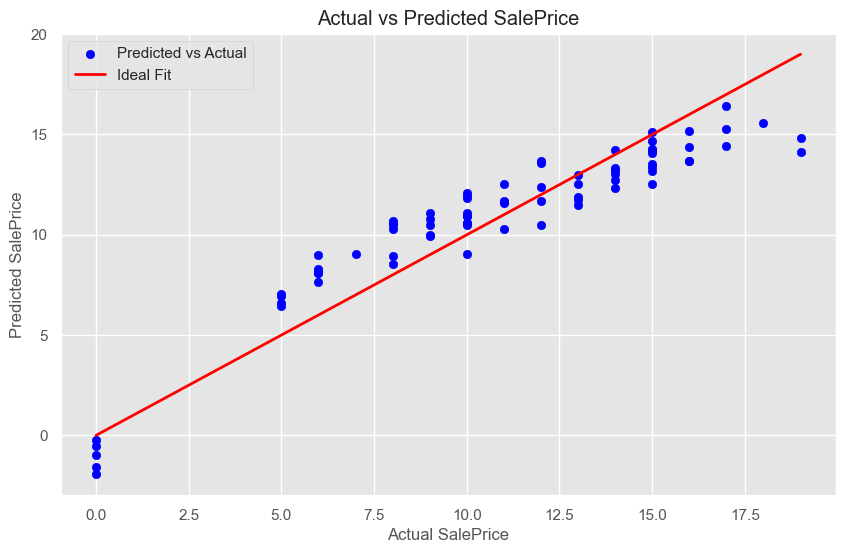

     Actual  Predicted     Error
78       10  11.083007 -1.083007
371      12  11.677088  0.322912
248       5   7.027990 -2.027990
55       10  10.529652 -0.529652
390       9   9.974837 -0.974837


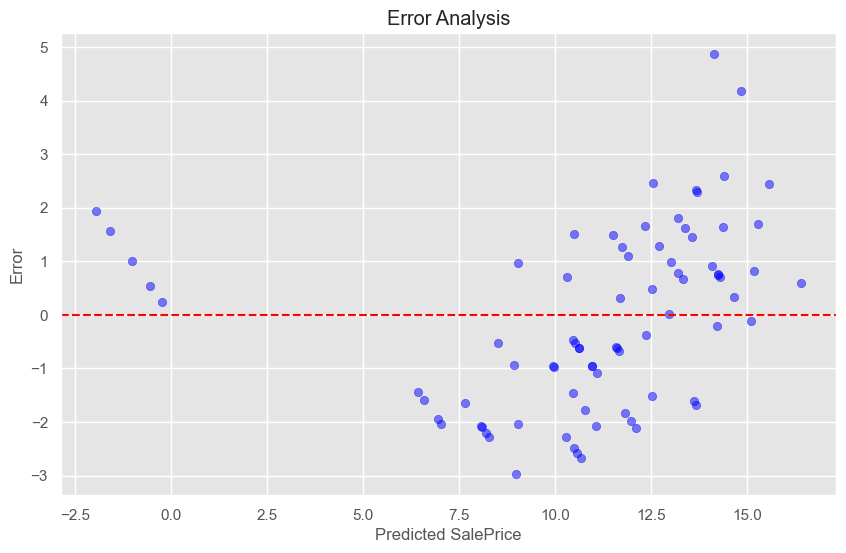

In [138]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Initialize and fit the model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on test data
X_test_prediction = lr.predict(X_test)

# Mean Absolute Error
mae = mean_absolute_error(y_test, X_test_prediction)
print('Mean Absolute Error: ', mae)

# Mean Squared Error
mse = mean_squared_error(y_test, X_test_prediction)
print('Mean Squared Error: ', mse)

# Root Mean Squared Error
rmse = np.sqrt(mse)
print('Root Mean Squared Error: ', rmse)

# R² Score
test_data_r2 = r2_score(y_test, X_test_prediction)
print('R² on Test data: ', test_data_r2)

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, X_test_prediction, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2, label='Ideal Fit')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice')
plt.legend()
plt.show()

# Error Analysis
errors_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': X_test_prediction,
    'Error': y_test - X_test_prediction
})
print(errors_df.head())

plt.figure(figsize=(10, 6))
plt.scatter(X_test_prediction, errors_df['Error'], alpha=0.5, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Error')
plt.title('Error Analysis')
plt.grid(True)
plt.show()

## KNN model

Best parameters for KNN:  {'algorithm': 'ball_tree', 'n_neighbors': 7, 'p': 2, 'weights': 'distance'}
Best score for KNN:  -11.139850294466113
Best RMSE for KNN:  3.3376414268860746

Training Data Metrics for KNN:
Mean Absolute Error:  0.0
Mean Squared Error:  0.0
Root Mean Squared Error:  0.0
R2 Score:  1.0

Test Data Metrics for KNN:
Mean Absolute Error:  2.7822890846282773
Mean Squared Error:  11.70138144239292
Root Mean Squared Error:  3.420728203525226
R2 Score:  0.4293414060734051


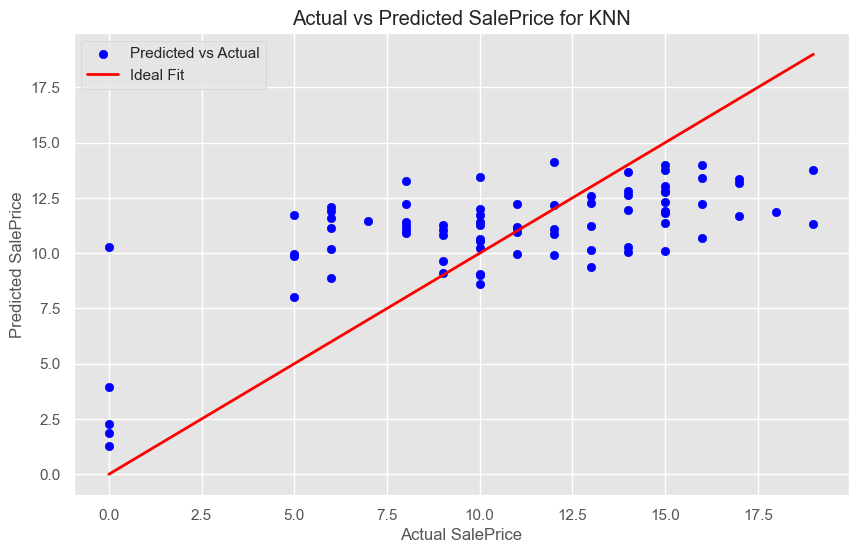

     Actual  Predicted     Error
78       10  11.083007 -1.083007
371      12  11.677088  0.322912
248       5   7.027990 -2.027990
55       10  10.529652 -0.529652
390       9   9.974837 -0.974837


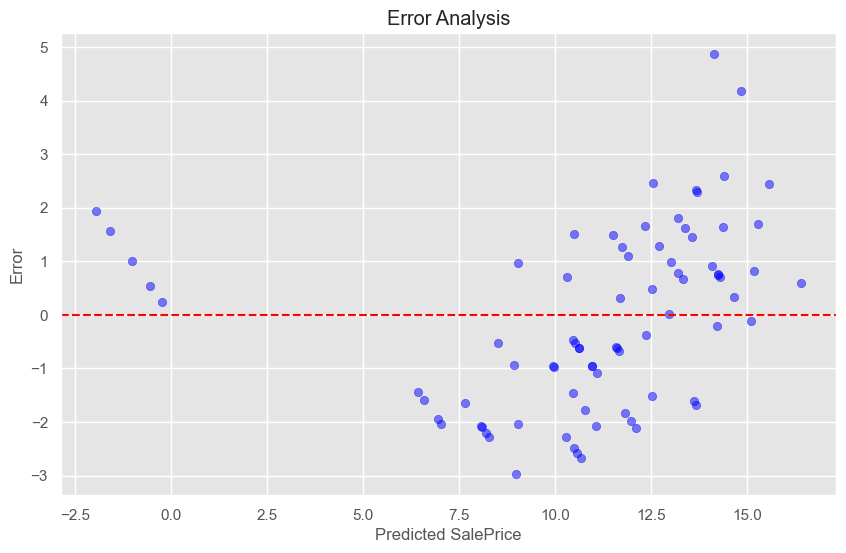

In [121]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
# Define the KNN model
knn = KNeighborsRegressor()

# Define the parameter grid for GridSearchCV
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 10, 100],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]
}
knn_cv = GridSearchCV(knn, param_grid_knn, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
knn_cv.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters for KNN: ", knn_cv.best_params_)
print("Best score for KNN: ", knn_cv.best_score_)
print("Best RMSE for KNN: ", np.sqrt(-1 * knn_cv.best_score_))

# Get the best estimator
best_knn = knn_cv.best_estimator_

# Predict on training data
y_train_pred = best_knn.predict(X_train)

# Predict on test data
y_test_pred = best_knn.predict(X_test)

# Calculate metrics for training data
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print("\nTraining Data Metrics for KNN:")
print("Mean Absolute Error: ", train_mae)
print("Mean Squared Error: ", train_mse)
print("Root Mean Squared Error: ", train_rmse)
print("R2 Score: ", train_r2)

# Calculate metrics for test data
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("\nTest Data Metrics for KNN:")
print("Mean Absolute Error: ", test_mae)
print("Mean Squared Error: ", test_mse)
print("Root Mean Squared Error: ", test_rmse)
print("R2 Score: ", test_r2)

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2, label='Ideal Fit')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice for KNN')
plt.legend()
plt.show()

# Error Analysis
errors_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': X_test_prediction,
    'Error': y_test - X_test_prediction
})
print(errors_df.head())

plt.figure(figsize=(10, 6))
plt.scatter(X_test_prediction, errors_df['Error'], alpha=0.5, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Error')
plt.title('Error Analysis')
plt.grid(True)
plt.show()

## SVM model

Best parameters for SVM:  {'C': 1.099749158180029, 'degree': 5, 'gamma': 2.154434690031882, 'kernel': 'linear'}
Best score for SVM:  -3.2976140626569226
Best RMSE for SVM:  1.8159333860736528

Training Data Metrics for SVM:
Mean Absolute Error:  1.2217412435223471
Mean Squared Error:  2.6897099203710524
Root Mean Squared Error:  1.6400335119658538
R2 Score:  0.8719461159751583

Test Data Metrics for SVM:
Mean Absolute Error:  1.4725632325244455
Mean Squared Error:  3.0322476289916076
Root Mean Squared Error:  1.7413350134283774
R2 Score:  0.8521218903155642


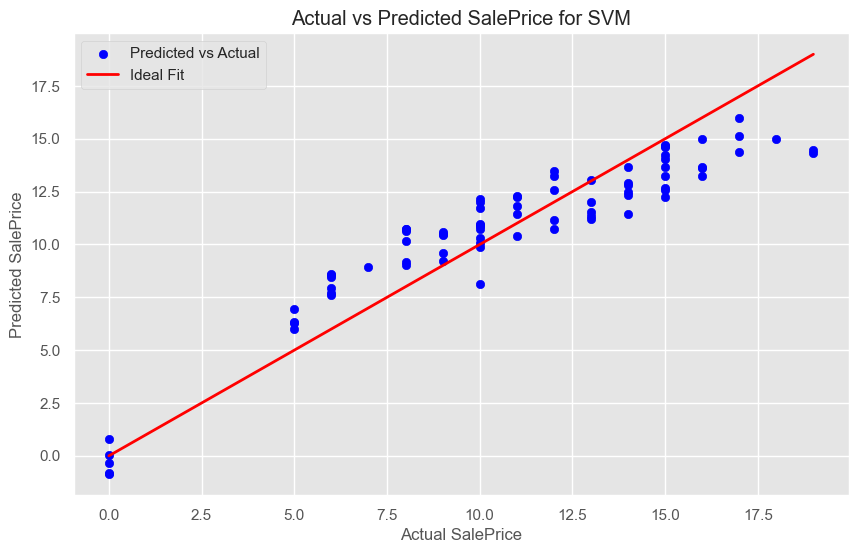

     Actual  Predicted     Error
78       10  11.083007 -1.083007
371      12  11.677088  0.322912
248       5   7.027990 -2.027990
55       10  10.529652 -0.529652
390       9   9.974837 -0.974837


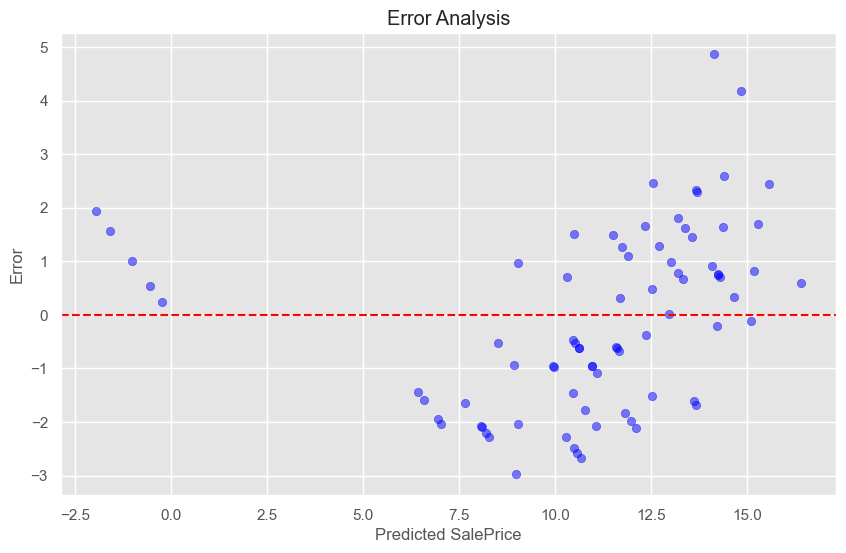

In [122]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
import matplotlib.pyplot as plt

# Define the SVM model
svm = SVR()

# Define the parameter distributions for RandomizedSearchCV
param_dist_svm = {
    'C': uniform(0.1, 10),
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'] + list(np.logspace(-3, 3, 10)),
    'degree': [3, 4, 5]
}

# Initialize RandomizedSearchCV
svm_random_search = RandomizedSearchCV(svm, param_distributions=param_dist_svm, n_iter=20, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, random_state=42)
svm_random_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters for SVM: ", svm_random_search.best_params_)
print("Best score for SVM: ", svm_random_search.best_score_)
print("Best RMSE for SVM: ", np.sqrt(-1 * svm_random_search.best_score_))

# Get the best estimator
best_svm = svm_random_search.best_estimator_

# Predict on training data
y_train_pred = best_svm.predict(X_train)

# Predict on test data
y_test_pred = best_svm.predict(X_test)

# Calculate metrics for training data
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print("\nTraining Data Metrics for SVM:")
print("Mean Absolute Error: ", train_mae)
print("Mean Squared Error: ", train_mse)
print("Root Mean Squared Error: ", train_rmse)
print("R2 Score: ", train_r2)

# Calculate metrics for test data
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("\nTest Data Metrics for SVM:")
print("Mean Absolute Error: ", test_mae)
print("Mean Squared Error: ", test_mse)
print("Root Mean Squared Error: ", test_rmse)
print("R2 Score: ", test_r2)

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2, label='Ideal Fit')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice for SVM')
plt.legend()
plt.show()

# Error Analysis
errors_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': X_test_prediction,
    'Error': y_test - X_test_prediction
})
print(errors_df.head())

plt.figure(figsize=(10, 6))
plt.scatter(X_test_prediction, errors_df['Error'], alpha=0.5, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Error')
plt.title('Error Analysis')
plt.grid(True)
plt.show()

## Decision Tree model

Best parameters for Decision Tree:  {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 2}
Best score for Decision Tree:  -9.063575493055131
Best RMSE for Decision Tree:  3.0105772690723502

Training Data Metrics for Decision Tree:
Mean Absolute Error:  1.2741421661838954
Mean Squared Error:  5.755731424983861
Root Mean Squared Error:  2.3991105487208926
R2 Score:  0.725976485869025

Test Data Metrics for Decision Tree:
Mean Absolute Error:  1.7504002375259078
Mean Squared Error:  9.812313915934766
Root Mean Squared Error:  3.132461319144223
R2 Score:  0.5214683590992649


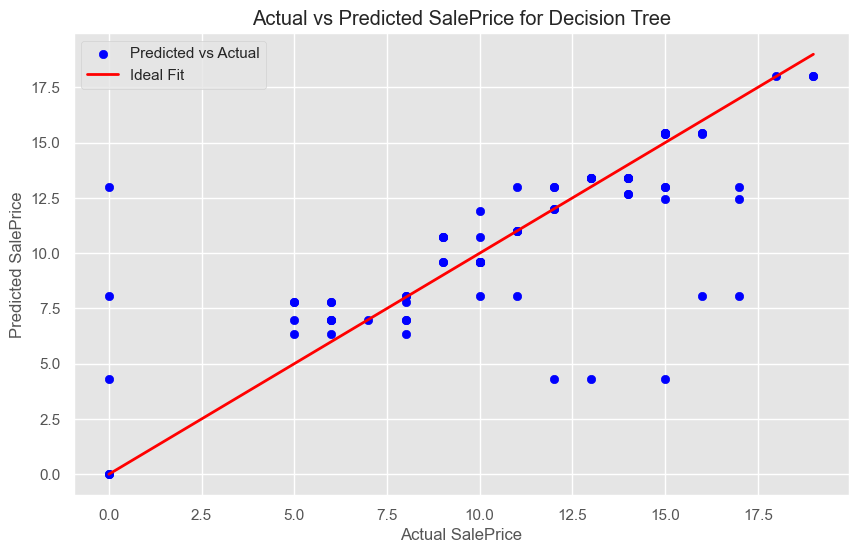

     Actual  Predicted     Error
78       10  11.083007 -1.083007
371      12  11.677088  0.322912
248       5   7.027990 -2.027990
55       10  10.529652 -0.529652
390       9   9.974837 -0.974837


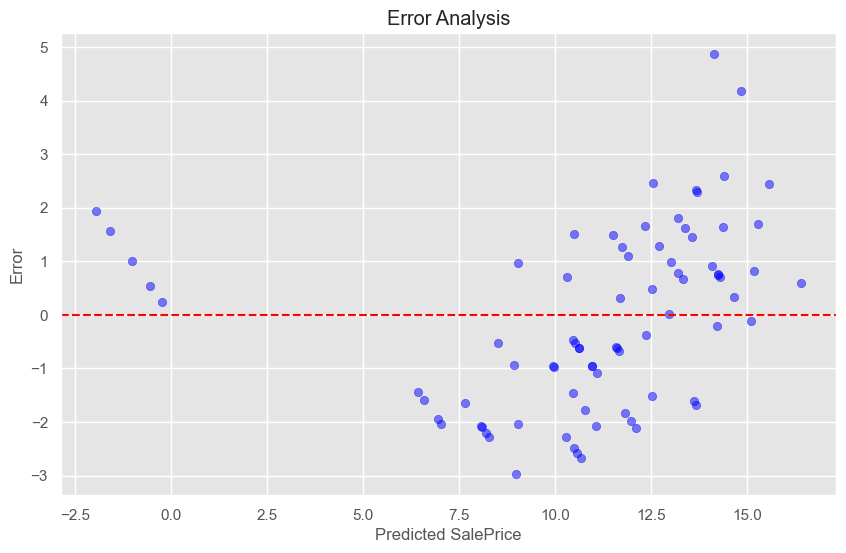

In [139]:
from sklearn.tree import DecisionTreeRegressor
# Define the Decision Tree model
dt = DecisionTreeRegressor(random_state=13)

# Define the parameter grid for GridSearchCV
param_grid_dt = {
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['auto', 'sqrt', 'log2']
}
dt_cv = GridSearchCV(dt, param_grid_dt, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
dt_cv.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters for Decision Tree: ", dt_cv.best_params_)
print("Best score for Decision Tree: ", dt_cv.best_score_)
print("Best RMSE for Decision Tree: ", np.sqrt(-1 * dt_cv.best_score_))

# Get the best estimator
best_dt = dt_cv.best_estimator_

# Predict on training data
y_train_pred = best_dt.predict(X_train)

# Predict on test data
y_test_pred = best_dt.predict(X_test)

# Calculate metrics for training data
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print("\nTraining Data Metrics for Decision Tree:")
print("Mean Absolute Error: ", train_mae)
print("Mean Squared Error: ", train_mse)
print("Root Mean Squared Error: ", train_rmse)
print("R2 Score: ", train_r2)

# Calculate metrics for test data
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("\nTest Data Metrics for Decision Tree:")
print("Mean Absolute Error: ", test_mae)
print("Mean Squared Error: ", test_mse)
print("Root Mean Squared Error: ", test_rmse)
print("R2 Score: ", test_r2)

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2, label='Ideal Fit')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice for Decision Tree')
plt.legend()
plt.show()

# Error Analysis
errors_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': X_test_prediction,
    'Error': y_test - X_test_prediction
})
print(errors_df.head())

plt.figure(figsize=(10, 6))
plt.scatter(X_test_prediction, errors_df['Error'], alpha=0.5, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Error')
plt.title('Error Analysis')
plt.grid(True)
plt.show()

## ElasticNet model

Best parameters for ElasticNet:  {'alpha': 0.1, 'l1_ratio': 0.9, 'max_iter': 1000}
Best score for ElasticNet:  -2.9116162706592053
Best RMSE for ElasticNet:  1.7063458824808073

Training Data Metrics for ElasticNet:
Mean Absolute Error:  1.3271587766577744
Mean Squared Error:  2.6917819099168825
Root Mean Squared Error:  1.640665081580297
R2 Score:  0.8718474710220379

Test Data Metrics for ElasticNet:
Mean Absolute Error:  1.5521618298198265
Mean Squared Error:  3.347595747036616
Root Mean Squared Error:  1.829643612028478
R2 Score:  0.8367428417368212


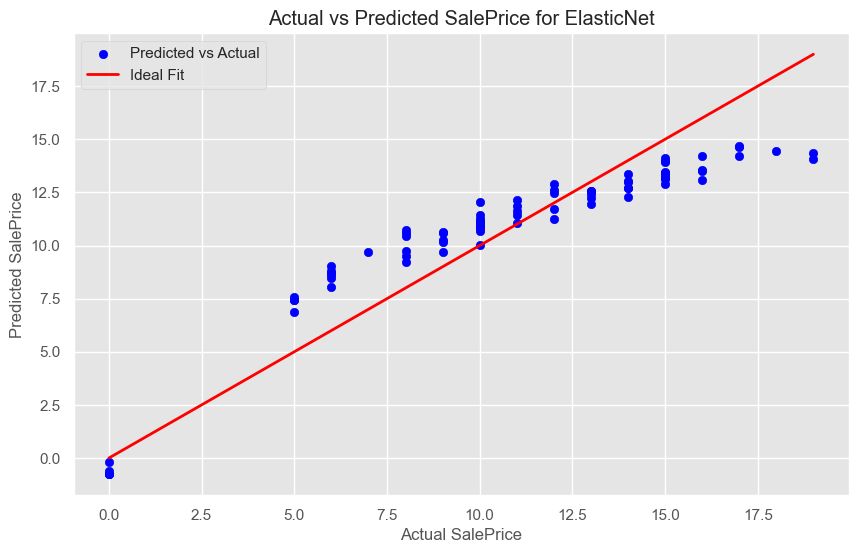

     Actual  Predicted     Error
78       10  11.083007 -1.083007
371      12  11.677088  0.322912
248       5   7.027990 -2.027990
55       10  10.529652 -0.529652
390       9   9.974837 -0.974837


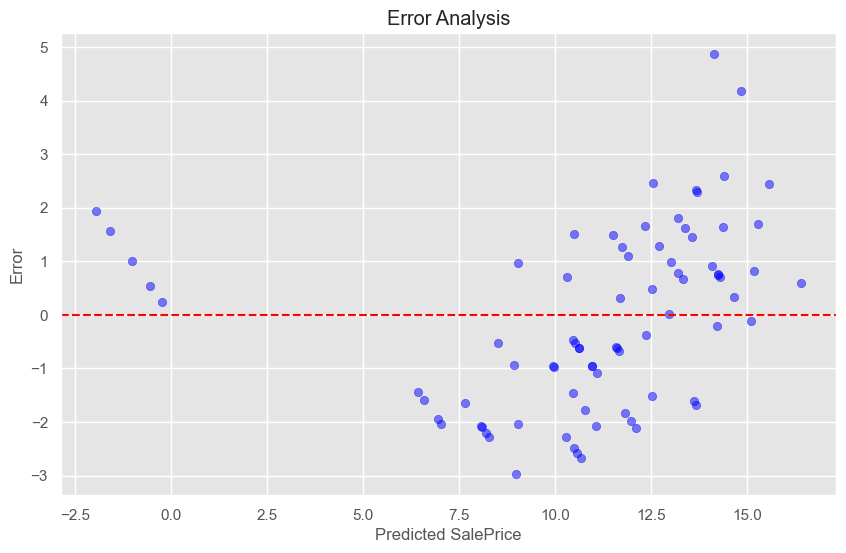

In [140]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Define the ElasticNet model
elasticnet = ElasticNet(random_state=13)

# Define the parameter grid for GridSearchCV
param_grid_en = {
    'alpha': [0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.5, 0.9],
    'max_iter': [1000, 2000, 3000]
}
en_cv = GridSearchCV(elasticnet, param_grid_en, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
en_cv.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters for ElasticNet: ", en_cv.best_params_)
print("Best score for ElasticNet: ", en_cv.best_score_)
print("Best RMSE for ElasticNet: ", np.sqrt(-1 * en_cv.best_score_))

# Get the best estimator
best_en = en_cv.best_estimator_

# Predict on training data
y_train_pred = best_en.predict(X_train)

# Predict on test data
y_test_pred = best_en.predict(X_test)

# Calculate metrics for training data
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print("\nTraining Data Metrics for ElasticNet:")
print("Mean Absolute Error: ", train_mae)
print("Mean Squared Error: ", train_mse)
print("Root Mean Squared Error: ", train_rmse)
print("R2 Score: ", train_r2)

# Calculate metrics for test data
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("\nTest Data Metrics for ElasticNet:")
print("Mean Absolute Error: ", test_mae)
print("Mean Squared Error: ", test_mse)
print("Root Mean Squared Error: ", test_rmse)
print("R2 Score: ", test_r2)

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2, label='Ideal Fit')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice for ElasticNet')
plt.legend()
plt.show()

# Error Analysis
errors_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': X_test_prediction,
    'Error': y_test - X_test_prediction
})
print(errors_df.head())

plt.figure(figsize=(10, 6))
plt.scatter(X_test_prediction, errors_df['Error'], alpha=0.5, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Error')
plt.title('Error Analysis')
plt.grid(True)
plt.show()

## AdaBoost Regressor model

Best parameters for AdaBoost:  {'learning_rate': 0.1, 'n_estimators': 100}
Best score for AdaBoost:  -0.14512346091400616
Best RMSE for AdaBoost:  0.3809507329222588

Training Data Metrics for AdaBoost:
Mean Absolute Error:  0.33841645469864273
Mean Squared Error:  0.14229187402439755
Root Mean Squared Error:  0.3772159514447892
R2 Score:  0.9932256534446346

Test Data Metrics for AdaBoost:
Mean Absolute Error:  0.34441085436951907
Mean Squared Error:  0.1491831574150713
Root Mean Squared Error:  0.38624235580147254
R2 Score:  0.9927245640809906


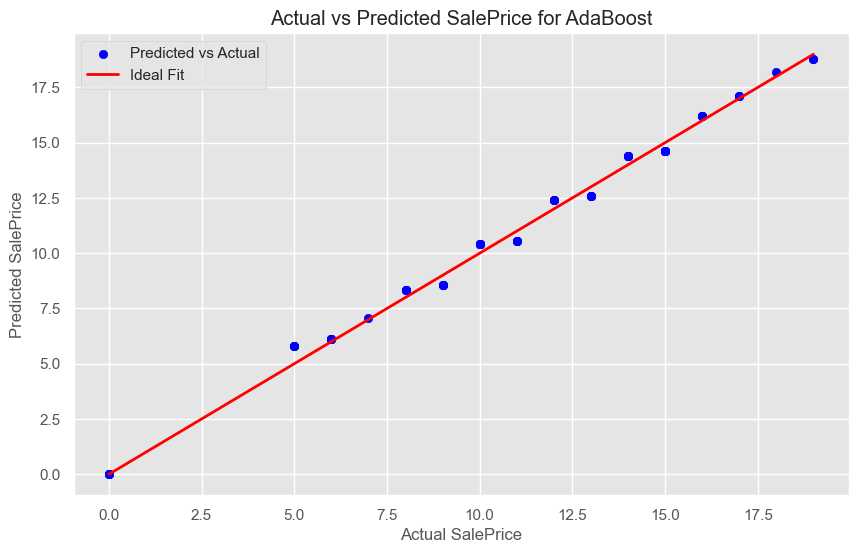

     Actual  Predicted     Error
78       10  11.083007 -1.083007
371      12  11.677088  0.322912
248       5   7.027990 -2.027990
55       10  10.529652 -0.529652
390       9   9.974837 -0.974837


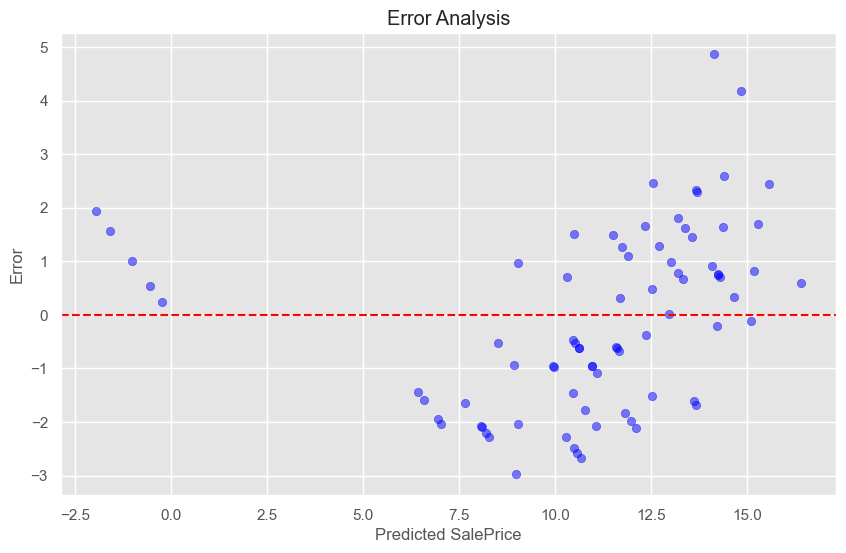

In [141]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Define the AdaBoost Regressor model
ada = AdaBoostRegressor(random_state=13)

# Define the parameter grid for GridSearchCV
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1]
}
ada_cv = GridSearchCV(ada, param_grid_ada, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
ada_cv.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters for AdaBoost: ", ada_cv.best_params_)
print("Best score for AdaBoost: ", ada_cv.best_score_)
print("Best RMSE for AdaBoost: ", np.sqrt(-1 * ada_cv.best_score_))

# Get the best estimator
best_ada = ada_cv.best_estimator_

# Predict on training data
y_train_pred = best_ada.predict(X_train)

# Predict on test data
y_test_pred = best_ada.predict(X_test)

# Calculate metrics for training data
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print("\nTraining Data Metrics for AdaBoost:")
print("Mean Absolute Error: ", train_mae)
print("Mean Squared Error: ", train_mse)
print("Root Mean Squared Error: ", train_rmse)
print("R2 Score: ", train_r2)

# Calculate metrics for test data
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("\nTest Data Metrics for AdaBoost:")
print("Mean Absolute Error: ", test_mae)
print("Mean Squared Error: ", test_mse)
print("Root Mean Squared Error: ", test_rmse)
print("R2 Score: ", test_r2)

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2, label='Ideal Fit')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice for AdaBoost')
plt.legend()
plt.show()

# Error Analysis
errors_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': X_test_prediction,
    'Error': y_test - X_test_prediction
})
print(errors_df.head())

plt.figure(figsize=(10, 6))
plt.scatter(X_test_prediction, errors_df['Error'], alpha=0.5, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Error')
plt.title('Error Analysis')
plt.grid(True)
plt.show()


## Random Forest Regressor

Best parameters:  {'max_depth': 10, 'min_samples_split': 3, 'n_estimators': 1000}
Best score:  -0.05027253661691863
Best RMSE:  0.22421537997407454

Training Data Metrics:
Mean Absolute Error:  0.010799999999999883
Mean Squared Error:  0.005510829015471153
Root Mean Squared Error:  0.07423495817652996
R2 Score:  0.9997376359977397

Test Data Metrics:
Mean Absolute Error:  0.021872784810126496
Mean Squared Error:  0.0029531643565400677
Root Mean Squared Error:  0.05434302491157506
R2 Score:  0.9998559786613543


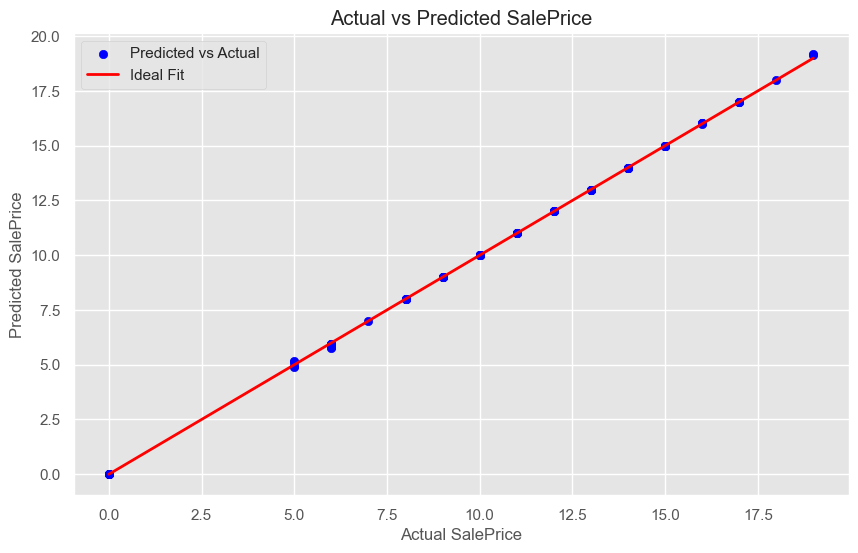

     Actual  Predicted     Error
78       10  11.083007 -1.083007
371      12  11.677088  0.322912
248       5   7.027990 -2.027990
55       10  10.529652 -0.529652
390       9   9.974837 -0.974837


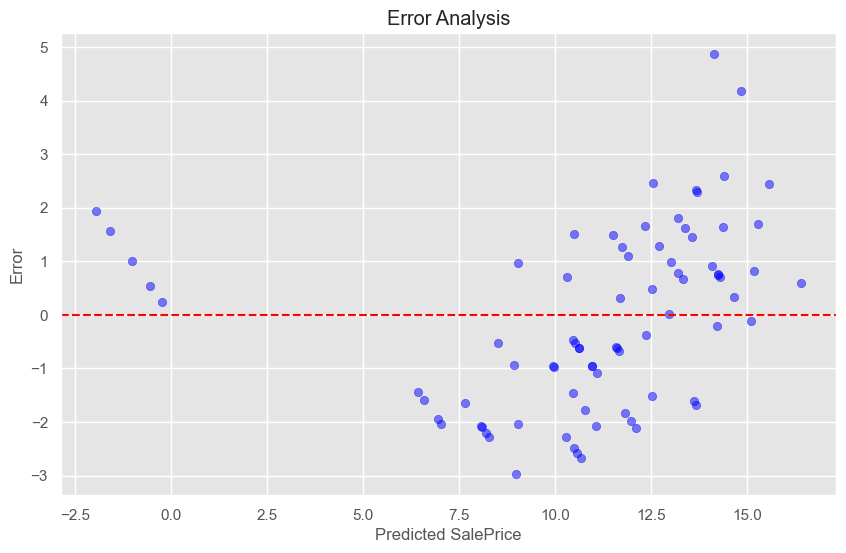

In [142]:
RFR = RandomForestRegressor(random_state=13)

# Define the parameter grid for GridSearchCV for hyper parametr tuning
param_grid_RFR = {
    'max_depth': [5, 10, 15],
    'n_estimators': [100, 250, 500 , 1000],
    'min_samples_split': [3, 5, 10]
}
rfr_cv = GridSearchCV(RFR, param_grid_RFR, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
rfr_cv.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters: ", rfr_cv.best_params_)
print("Best score: ", rfr_cv.best_score_)
print("Best RMSE: ", np.sqrt(-1 * rfr_cv.best_score_))

# Get the best estimator
best_rfr = rfr_cv.best_estimator_

# Predict on training data
y_train_pred = best_rfr.predict(X_train)

# Predict on test data
y_test_pred = best_rfr.predict(X_test)

# Calculate metrics for training data
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print("\nTraining Data Metrics:")
print("Mean Absolute Error: ", train_mae)
print("Mean Squared Error: ", train_mse)
print("Root Mean Squared Error: ", train_rmse)
print("R2 Score: ", train_r2)

# Calculate metrics for test data
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("\nTest Data Metrics:")
print("Mean Absolute Error: ", test_mae)
print("Mean Squared Error: ", test_mse)
print("Root Mean Squared Error: ", test_rmse)
print("R2 Score: ", test_r2)

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2, label='Ideal Fit')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice')
plt.legend()
plt.show()

# Error Analysis
errors_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': X_test_prediction,
    'Error': y_test - X_test_prediction
})
print(errors_df.head())

plt.figure(figsize=(10, 6))
plt.scatter(X_test_prediction, errors_df['Error'], alpha=0.5, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Error')
plt.title('Error Analysis')
plt.grid(True)
plt.show()


## XGB Regressor

Best parameters:  {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 300, 'subsample': 1.0}
Best score:  -0.04268222886747092
Best RMSE:  0.2065967784537574

Training Data Metrics:
Mean Absolute Error:  0.0009876869255463193
Mean Squared Error:  1.5216030115464723e-05
Root Mean Squared Error:  0.003900773015116968
R2 Score:  0.9999992755829389

Test Data Metrics:
Mean Absolute Error:  0.019649372495050672
Mean Squared Error:  0.012590764965521476
Root Mean Squared Error:  0.11220857794982288
R2 Score:  0.9993859675229751


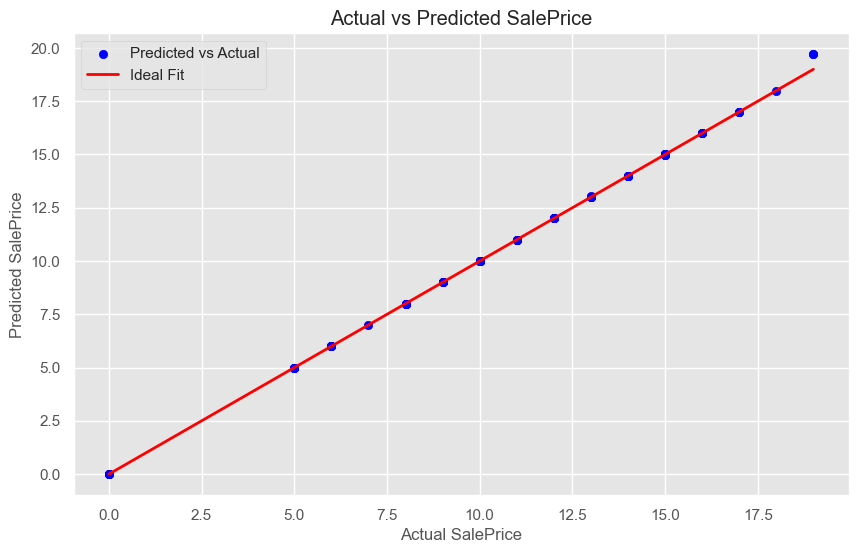

     Actual  Predicted     Error
78       10  11.083007 -1.083007
371      12  11.677088  0.322912
248       5   7.027990 -2.027990
55       10  10.529652 -0.529652
390       9   9.974837 -0.974837


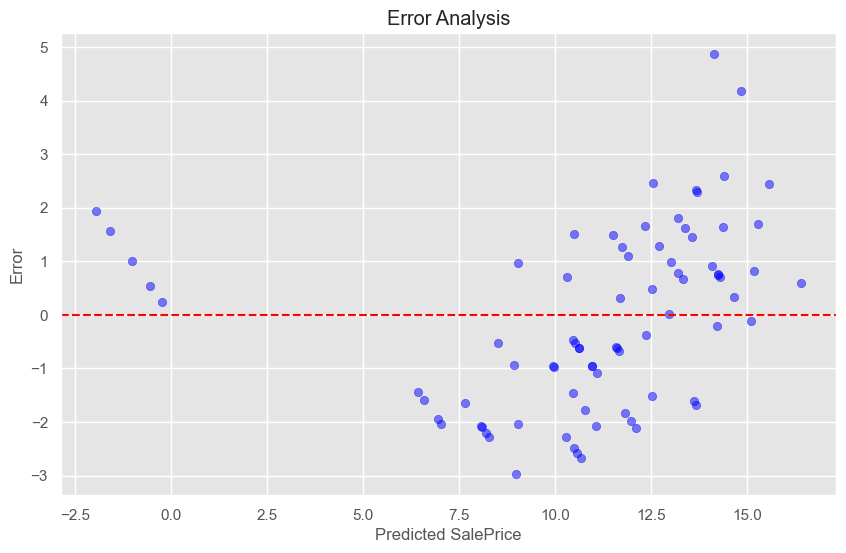

In [143]:
XGB = XGBRegressor(random_state=13)
param_grid_XGB = {
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [300],
    'max_depth': [3],
    'min_child_weight': [1,2,3],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
}
xgb_cv = GridSearchCV(XGB, param_grid_XGB, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
xgb_cv.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters: ", xgb_cv.best_params_)
print("Best score: ", xgb_cv.best_score_)
print("Best RMSE: ", np.sqrt(-1 * xgb_cv.best_score_))

# Get the best estimator
best_xgb = xgb_cv.best_estimator_

# Predict on training data
y_train_pred = best_xgb.predict(X_train)

# Predict on test data
y_test_pred = best_xgb.predict(X_test)

# Calculate metrics for training data
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print("\nTraining Data Metrics:")
print("Mean Absolute Error: ", train_mae)
print("Mean Squared Error: ", train_mse)
print("Root Mean Squared Error: ", train_rmse)
print("R2 Score: ", train_r2)

# Calculate metrics for test data
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("\nTest Data Metrics:")
print("Mean Absolute Error: ", test_mae)
print("Mean Squared Error: ", test_mse)
print("Root Mean Squared Error: ", test_rmse)
print("R2 Score: ", test_r2)

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2, label='Ideal Fit')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice')
plt.legend()
plt.show()

# Error Analysis
errors_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': X_test_prediction,
    'Error': y_test - X_test_prediction
})
print(errors_df.head())

plt.figure(figsize=(10, 6))
plt.scatter(X_test_prediction, errors_df['Error'], alpha=0.5, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Error')
plt.title('Error Analysis')
plt.grid(True)
plt.show()

## Ridge regressor

Best parameters:  {'alpha': 3, 'solver': 'sag'}
Best score:  -2.9845448335626465
Best RMSE:  1.727583524337578

Training Data Metrics:
Mean Absolute Error:  1.2736177391360726
Mean Squared Error:  2.4367225205224
Root Mean Squared Error:  1.5610004870346452
R2 Score:  0.8839905446009397

Test Data Metrics:
Mean Absolute Error:  1.4269864284161697
Mean Squared Error:  2.8173907343667914
Root Mean Squared Error:  1.678508485044622
R2 Score:  0.8626001346139535


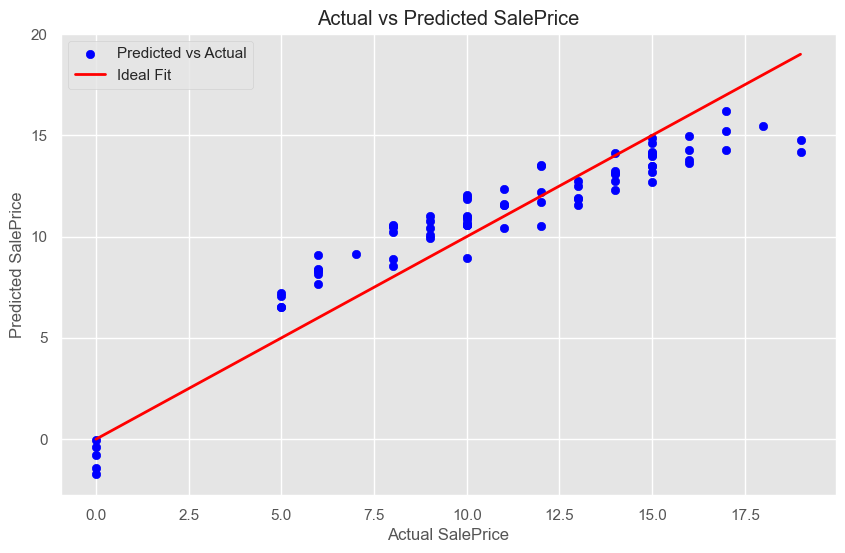

     Actual  Predicted     Error
78       10  11.083007 -1.083007
371      12  11.677088  0.322912
248       5   7.027990 -2.027990
55       10  10.529652 -0.529652
390       9   9.974837 -0.974837


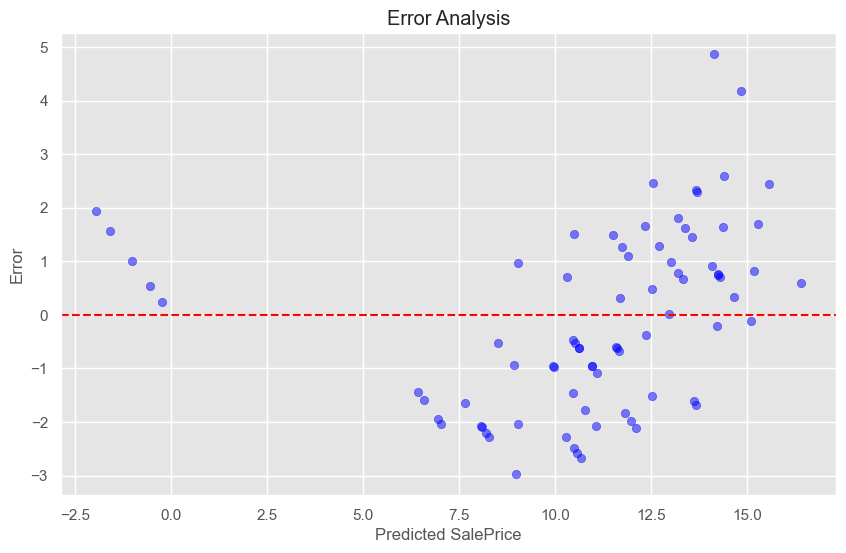

In [144]:
# Initialize the Ridge regressor
ridge = Ridge()

# Define the parameter grid for GridSearchCV
param_grid_ridge = {
    'alpha': [0.05, 0.1, 1, 3, 5, 10],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag']
}

# Perform GridSearchCV
ridge_cv = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
ridge_cv.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters: ", ridge_cv.best_params_)
print("Best score: ", ridge_cv.best_score_)
print("Best RMSE: ", np.sqrt(-1 * ridge_cv.best_score_))
# Get the best estimator
best_ridge = ridge_cv.best_estimator_

# Predict on training data
y_train_pred = best_ridge.predict(X_train)

# Predict on test data
y_test_pred = best_ridge.predict(X_test)

# Calculate metrics for training data
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print("\nTraining Data Metrics:")
print("Mean Absolute Error: ", train_mae)
print("Mean Squared Error: ", train_mse)
print("Root Mean Squared Error: ", train_rmse)
print("R2 Score: ", train_r2)

# Calculate metrics for test data
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("\nTest Data Metrics:")
print("Mean Absolute Error: ", test_mae)
print("Mean Squared Error: ", test_mse)
print("Root Mean Squared Error: ", test_rmse)
print("R2 Score: ", test_r2)

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2, label='Ideal Fit')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice')
plt.legend()
plt.show()

# Error Analysis
errors_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': X_test_prediction,
    'Error': y_test - X_test_prediction
})
print(errors_df.head())

plt.figure(figsize=(10, 6))
plt.scatter(X_test_prediction, errors_df['Error'], alpha=0.5, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Error')
plt.title('Error Analysis')
plt.grid(True)
plt.show()

# Overall calculate matrix

In [145]:
# Define a function to calculate metrics
def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Predict on training data
    y_train_pred = model.predict(X_train)

    # Predict on test data
    y_test_pred = model.predict(X_test)

    # Calculate metrics for training data
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train, y_train_pred)

    # Calculate metrics for test data
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, y_test_pred)

    return {
        'Train MAE': train_mae,
        'Train MSE': train_mse,
        'Train RMSE': train_rmse,
        'Train R2': train_r2,
        'Test MAE': test_mae,
        'Test MSE': test_mse,
        'Test RMSE': test_rmse,
        'Test R2': test_r2
    }

# Initialize models
models = {
    'Linear Regression': lr,
    'Decision Tree': dt_cv.best_estimator_,
    'Random Forest': rfr_cv.best_estimator_,
    'K-Nearest Neighbors': knn_cv.best_estimator_,
    'Support Vector Machine':svm_random_search.best_estimator_,
    'XGBoost': xgb_cv.best_estimator_,
    'Ridge': ridge_cv.best_estimator_,
    'ElasticNet': en_cv.best_estimator_,
    'AdaBoost': ada_cv.best_estimator_,
}

# Create a DataFrame to store results
results = []

# Evaluate each model
for name, model in models.items():
    metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
    results.append({'Model': name, **metrics})

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Print results
print(results_df)


                    Model  Train MAE  Train MSE  Train RMSE  Train R2  \
0       Linear Regression   1.274936   2.425744    1.557480  0.884513   
1           Decision Tree   1.274142   5.755731    2.399111  0.725976   
2           Random Forest   0.010800   0.005511    0.074235  0.999738   
3     K-Nearest Neighbors   0.000000   0.000000    0.000000  1.000000   
4  Support Vector Machine   1.221741   2.689710    1.640034  0.871946   
5                 XGBoost   0.000988   0.000015    0.003901  0.999999   
6                   Ridge   1.273618   2.436723    1.561000  0.883991   
7              ElasticNet   1.327159   2.691782    1.640665  0.871847   
8                AdaBoost   0.338416   0.142292    0.377216  0.993226   

   Test MAE   Test MSE  Test RMSE   Test R2  
0  1.421910   2.792218   1.670993  0.863828  
1  1.750400   9.812314   3.132461  0.521468  
2  0.021873   0.002953   0.054343  0.999856  
3  2.782289  11.701381   3.420728  0.429341  
4  1.472563   3.032248   1.741335  0.85

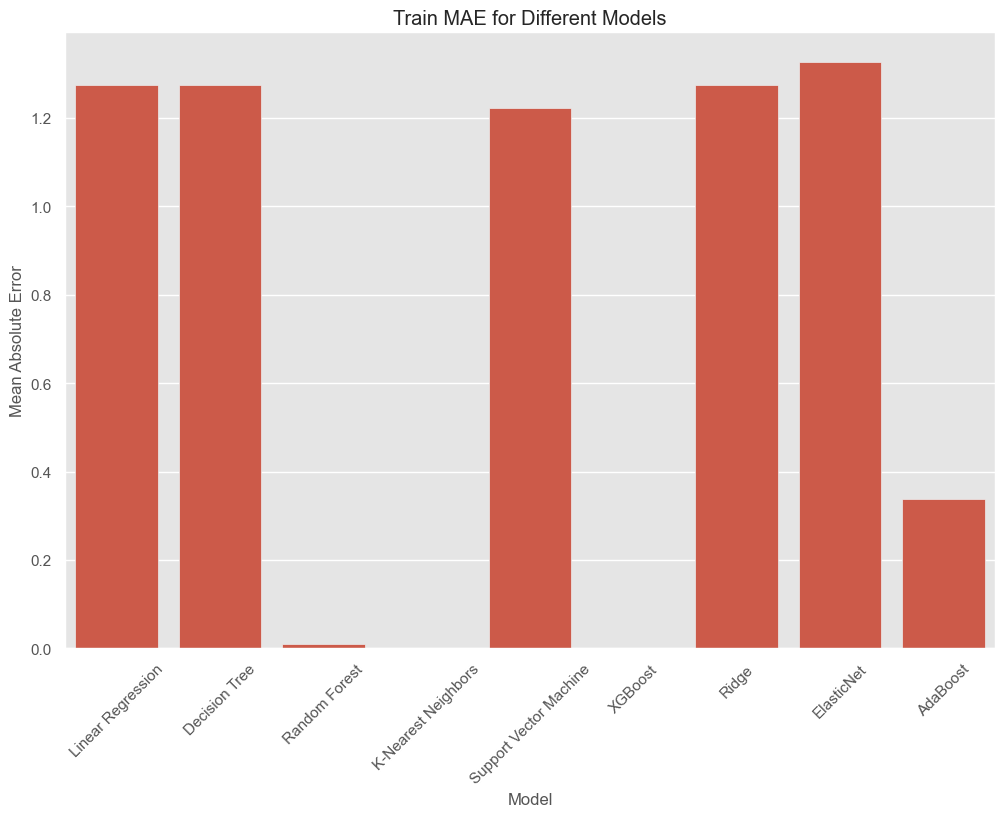

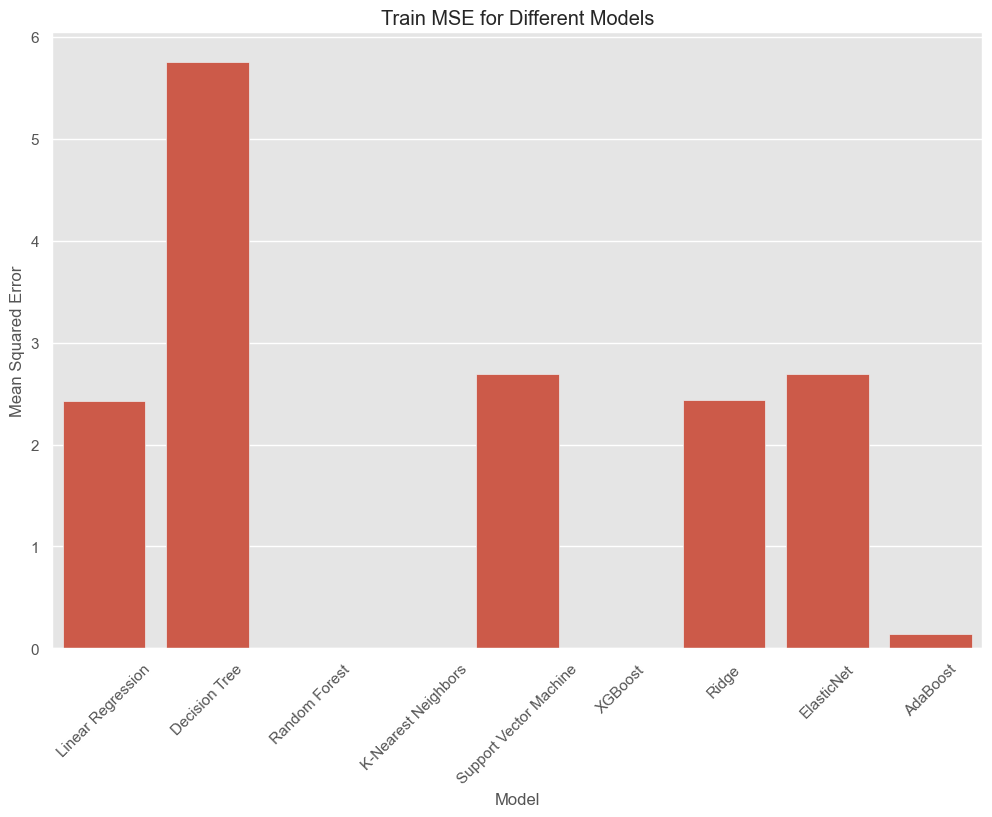

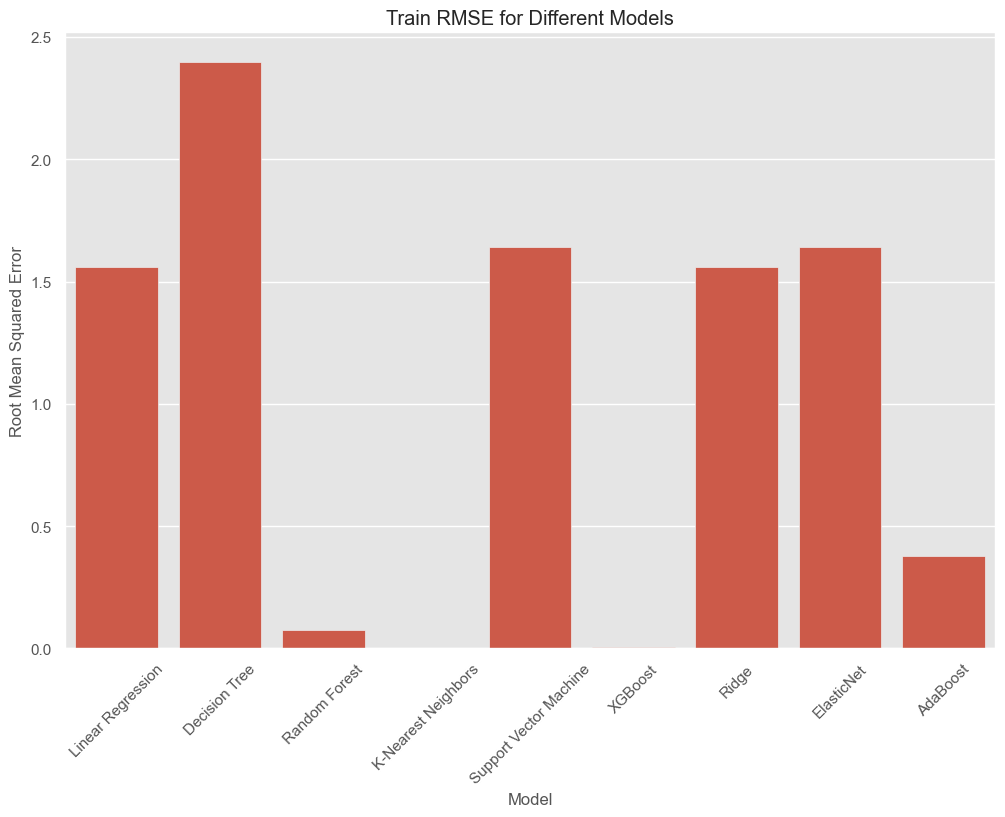

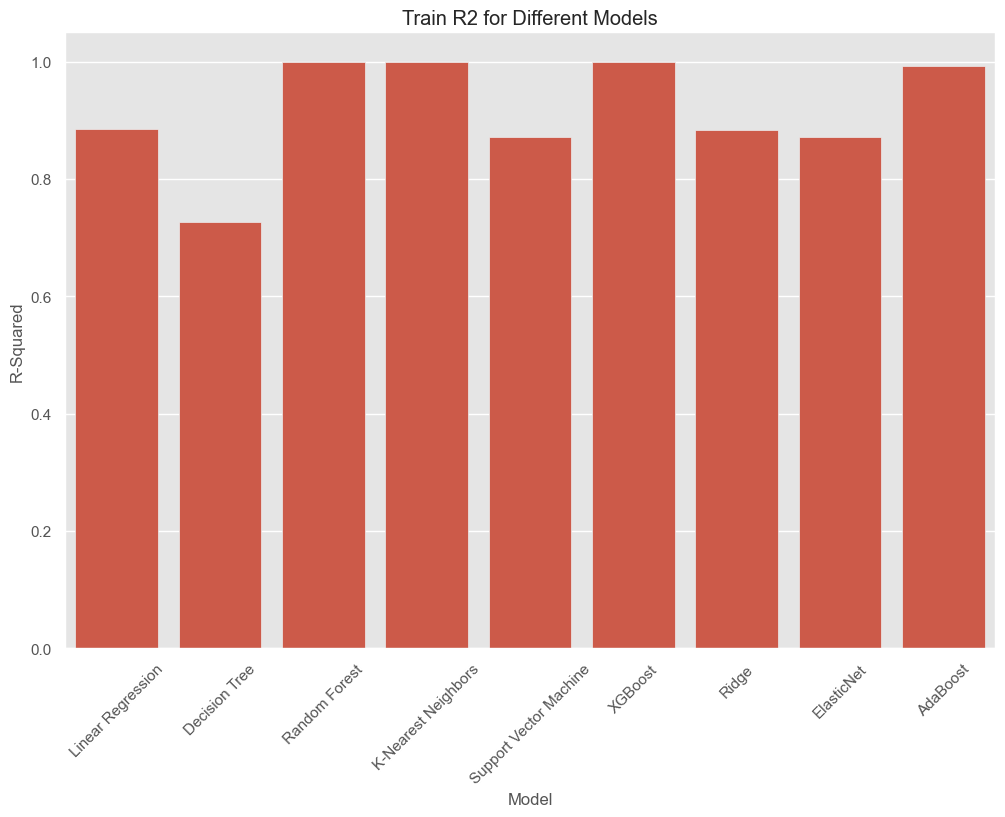

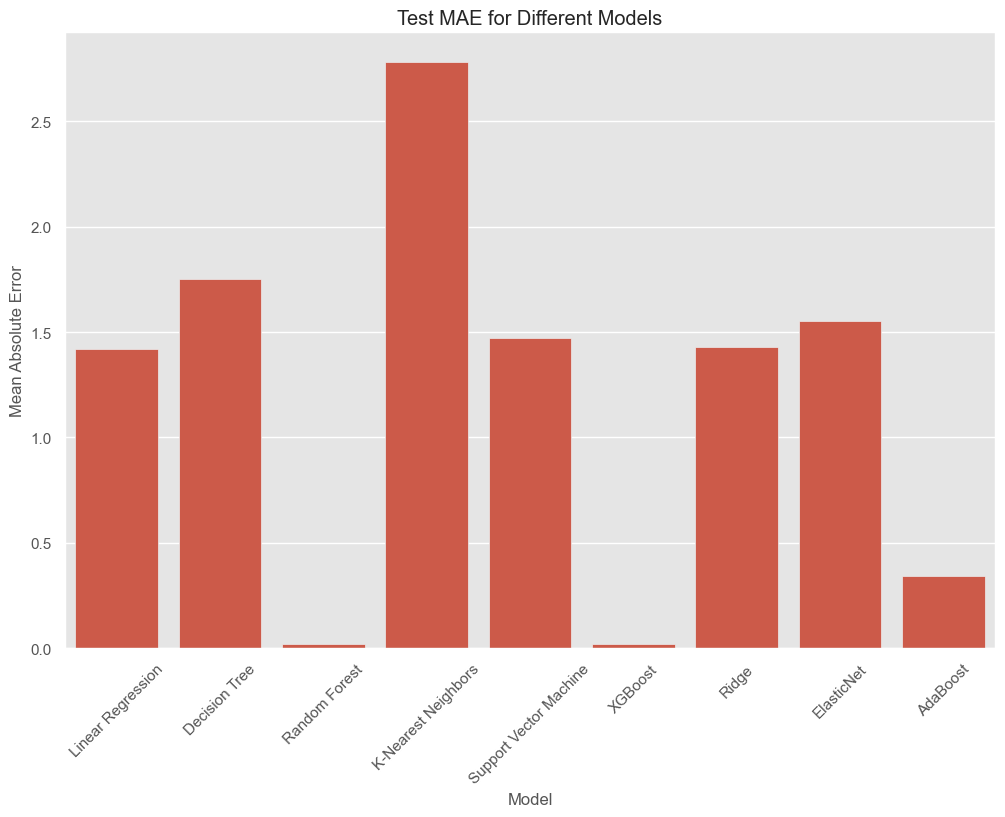

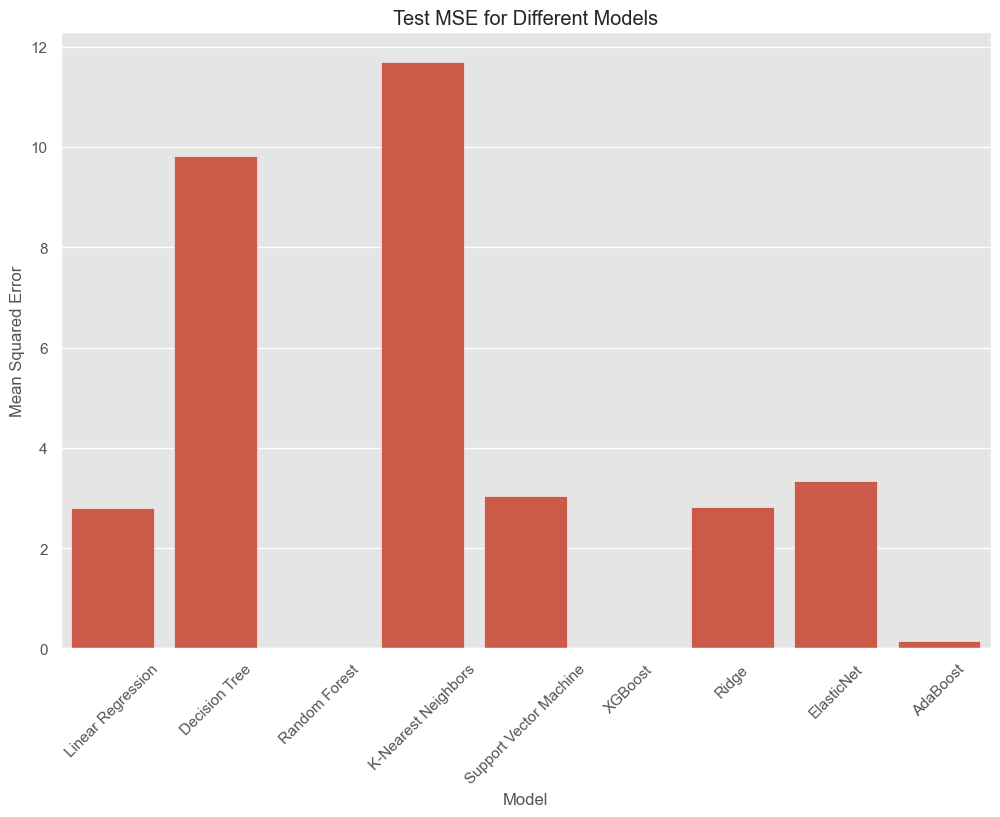

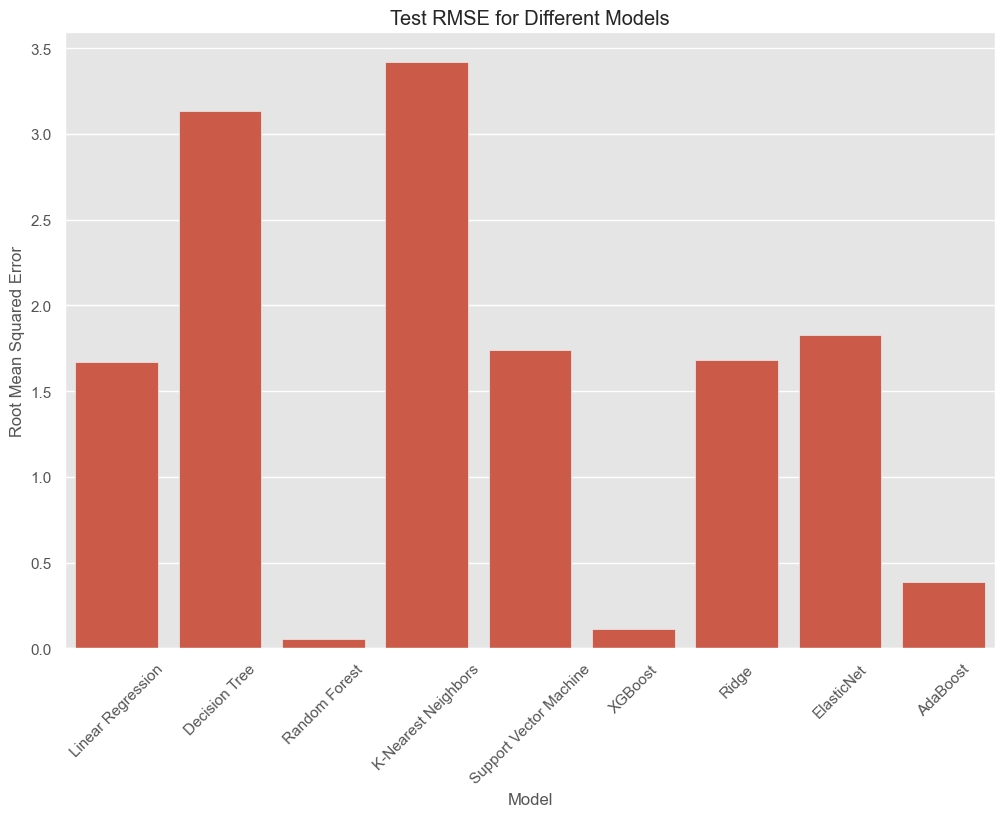

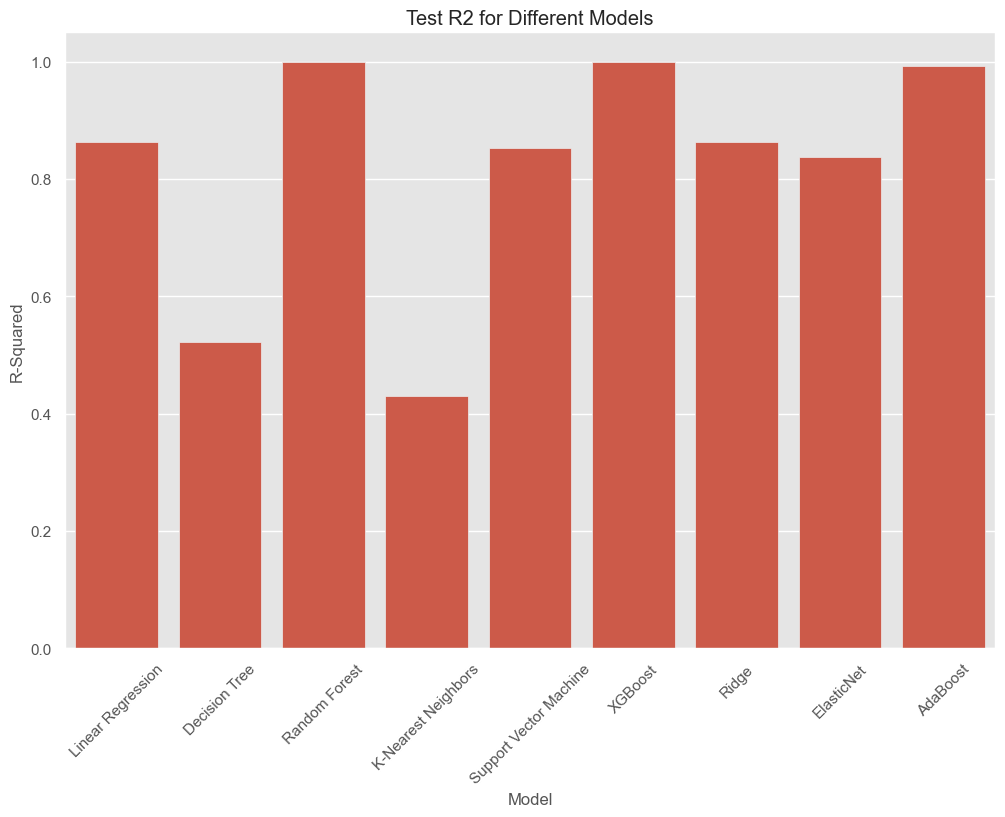

                    Model  Train MAE  Train MSE  Train RMSE  Train R2  \
0       Linear Regression   1.274936   2.425744    1.557480  0.884513   
1           Decision Tree   1.274142   5.755731    2.399111  0.725976   
2           Random Forest   0.010800   0.005511    0.074235  0.999738   
3     K-Nearest Neighbors   0.000000   0.000000    0.000000  1.000000   
4  Support Vector Machine   1.221741   2.689710    1.640034  0.871946   
5                 XGBoost   0.000988   0.000015    0.003901  0.999999   
6                   Ridge   1.273618   2.436723    1.561000  0.883991   
7              ElasticNet   1.327159   2.691782    1.640665  0.871847   
8                AdaBoost   0.338416   0.142292    0.377216  0.993226   

   Test MAE   Test MSE  Test RMSE   Test R2  
0  1.421910   2.792218   1.670993  0.863828  
1  1.750400   9.812314   3.132461  0.521468  
2  0.021873   0.002953   0.054343  0.999856  
3  2.782289  11.701381   3.420728  0.429341  
4  1.472563   3.032248   1.741335  0.85

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot the metrics
def plot_metrics(df, metric, title, ylabel):
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Model', y=metric, data=df)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.show()

# Plot metrics for training data
plot_metrics(results_df, 'Train MAE', 'Train MAE for Different Models', 'Mean Absolute Error')
plot_metrics(results_df, 'Train MSE', 'Train MSE for Different Models', 'Mean Squared Error')
plot_metrics(results_df, 'Train RMSE', 'Train RMSE for Different Models', 'Root Mean Squared Error')
plot_metrics(results_df, 'Train R2', 'Train R2 for Different Models', 'R-Squared')

# Plot metrics for test data
plot_metrics(results_df, 'Test MAE', 'Test MAE for Different Models', 'Mean Absolute Error')
plot_metrics(results_df, 'Test MSE', 'Test MSE for Different Models', 'Mean Squared Error')
plot_metrics(results_df, 'Test RMSE', 'Test RMSE for Different Models', 'Root Mean Squared Error')
plot_metrics(results_df, 'Test R2', 'Test R2 for Different Models', 'R-Squared')

# Print the results DataFrame for reference
print(results_df)


#### Finding the best model


✅ Best Model: Random Forest

**Train Metrics**
Train MAE: 0.0108
Train MSE: 0.0055
Train RMSE: 0.0742
Train R2: 0.9997

**Test Metrics**
Test MAE: 0.0219
Test MSE: 0.0030
Test RMSE: 0.0543
Test R2: 0.9999


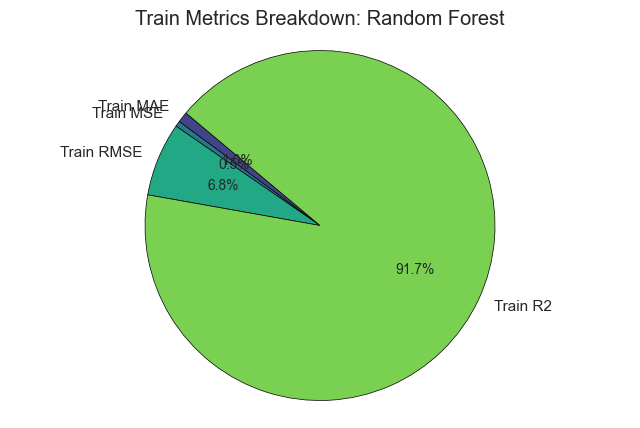

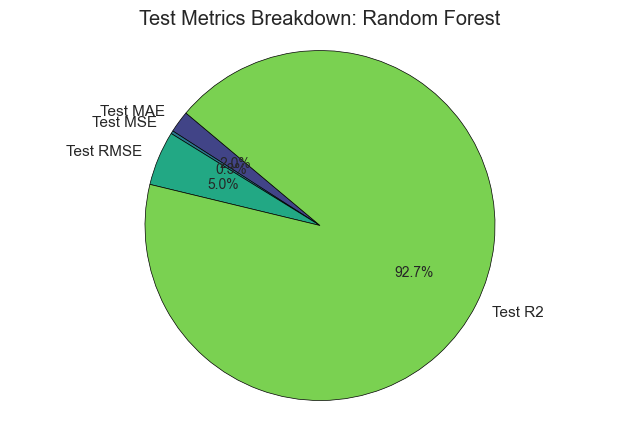

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Find the best model based on lowest Test RMSE
best_model = results_df.loc[results_df['Test RMSE'].idxmin()]

print("\n==============================")
print(f"✅ Best Model: {best_model['Model']}")
print("==============================")
print("\n**Train Metrics**")
for metric in ['Train MAE', 'Train MSE', 'Train RMSE', 'Train R2']:
    print(f"{metric}: {best_model[metric]:.4f}")

print("\n**Test Metrics**")
for metric in ['Test MAE', 'Test MSE', 'Test RMSE', 'Test R2']:
    print(f"{metric}: {best_model[metric]:.4f}")

# 2️⃣ Pie Chart for Train Metrics
train_metrics = best_model[['Train MAE', 'Train MSE', 'Train RMSE', 'Train R2']]

plt.figure(figsize=(8, 5))
plt.pie(
    train_metrics,
    labels=train_metrics.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("viridis", len(train_metrics)),
    wedgeprops={'edgecolor': 'black'}
)
plt.title(f'Train Metrics Breakdown: {best_model["Model"]}')
plt.axis('equal')
plt.show()

# 3️⃣ Pie Chart for Test Metrics
test_metrics = best_model[['Test MAE', 'Test MSE', 'Test RMSE', 'Test R2']]

plt.figure(figsize=(8, 5))
plt.pie(
    test_metrics,
    labels=test_metrics.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("viridis", len(test_metrics)),
    wedgeprops={'edgecolor': 'black'}
)
plt.title(f'Test Metrics Breakdown: {best_model["Model"]}')
plt.axis('equal')
plt.show()


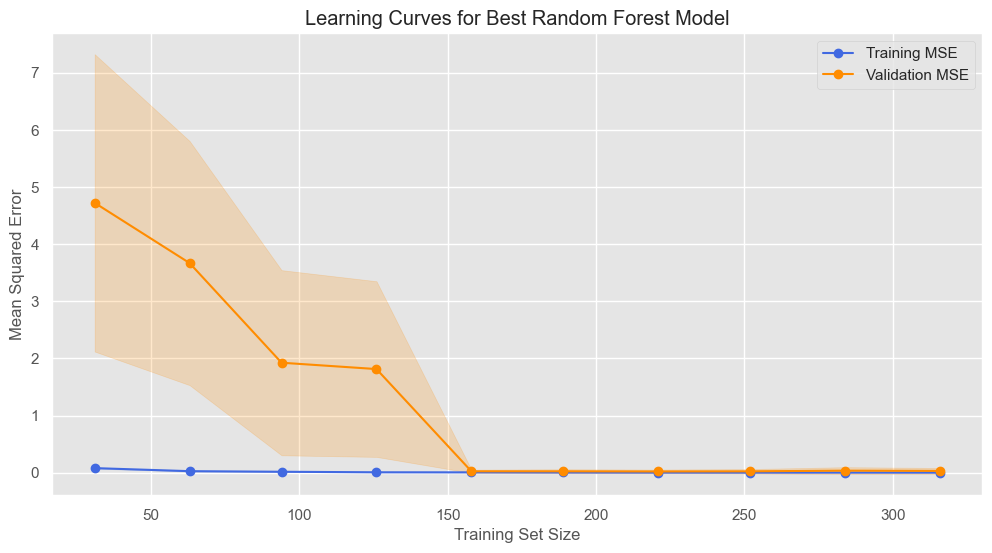


📊 Learning and Validation Scores:
 Training Size  Train MSE Mean  Train MSE Std  Validation MSE Mean  Validation MSE Std
            31          0.0812         0.0085               4.7241              2.6022
            63          0.0278         0.0072               3.6702              2.1367
            94          0.0175         0.0039               1.9260              1.6201
           126          0.0083         0.0033               1.8149              1.5372
           158          0.0071         0.0022               0.0254              0.0288
           189          0.0046         0.0010               0.0255              0.0360
           221          0.0033         0.0003               0.0227              0.0333
           252          0.0028         0.0004               0.0253              0.0396
           284          0.0032         0.0014               0.0366              0.0613
           316          0.0028         0.0016               0.0322              0.0519


In [148]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestRegressor

# Define your best model with your best hyperparameters
best_rf_model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=5,
    min_samples_split=3,
    random_state=42
)

# Function to plot learning curves
def plot_learning_curves(model, X, y):
    train_sizes, train_scores, validation_scores = learning_curve(
        model,
        X, y,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='neg_mean_squared_error',
        cv=5,
        n_jobs=-1
    )

    train_mean = -np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    validation_mean = -np.mean(validation_scores, axis=1)
    validation_std = np.std(validation_scores, axis=1)

    plt.figure(figsize=(12, 6))
    plt.plot(train_sizes, train_mean, 'o-', color='royalblue', label='Training MSE')
    plt.plot(train_sizes, validation_mean, 'o-', color='darkorange', label='Validation MSE')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='royalblue')
    plt.fill_between(train_sizes, validation_mean - validation_std, validation_mean + validation_std, alpha=0.2, color='darkorange')
    plt.title('Learning Curves for Best Random Forest Model')
    plt.xlabel('Training Set Size')
    plt.ylabel('Mean Squared Error')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

# Function to print scores table
def print_learning_curves_scores(model, X, y):
    train_sizes, train_scores, validation_scores = learning_curve(
        model,
        X, y,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='neg_mean_squared_error',
        cv=5,
        n_jobs=-1
    )

    train_mean = -np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    validation_mean = -np.mean(validation_scores, axis=1)
    validation_std = np.std(validation_scores, axis=1)

    scores_df = pd.DataFrame({
        'Training Size': train_sizes,
        'Train MSE Mean': train_mean.round(4),
        'Train MSE Std': train_std.round(4),
        'Validation MSE Mean': validation_mean.round(4),
        'Validation MSE Std': validation_std.round(4)
    })
    print("\n📊 Learning and Validation Scores:")
    print(scores_df.to_string(index=False))

plot_learning_curves(best_rf_model, X, y)
print_learning_curves_scores(best_rf_model, X, y)


In [149]:
best_rf_model.fit(X_train, y_train)
predictions = best_rf_model.predict(X_test)

# Create a DataFrame for easy viewing
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

# Show first 10 predictions
print(results_df.head(10))

     Actual  Predicted
78       10  10.000000
371      12  12.000000
248       5   5.161418
55       10  10.000000
390       9   9.000000
223      13  13.000000
42       18  18.004738
234       6   5.784992
316       0   0.000000
116      14  14.000000


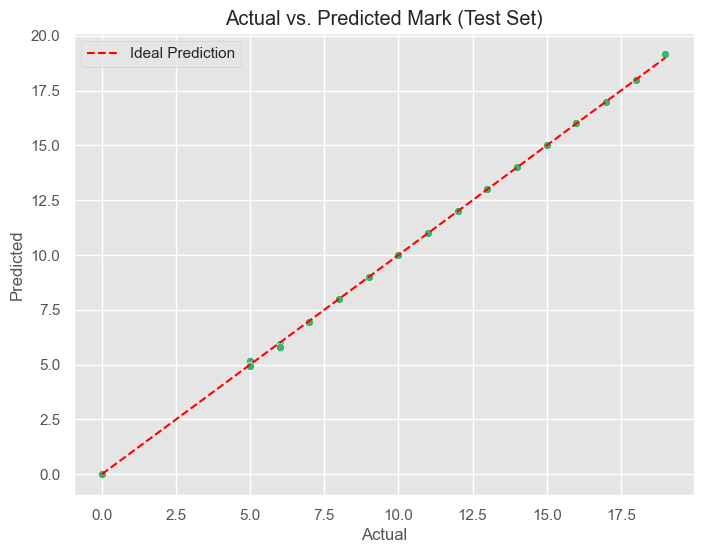

In [259]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=predictions, color='mediumseagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Ideal Prediction')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted Mark (Test Set)')
plt.legend()
plt.grid(True)
plt.show()


#### Residual Plot (Errors)

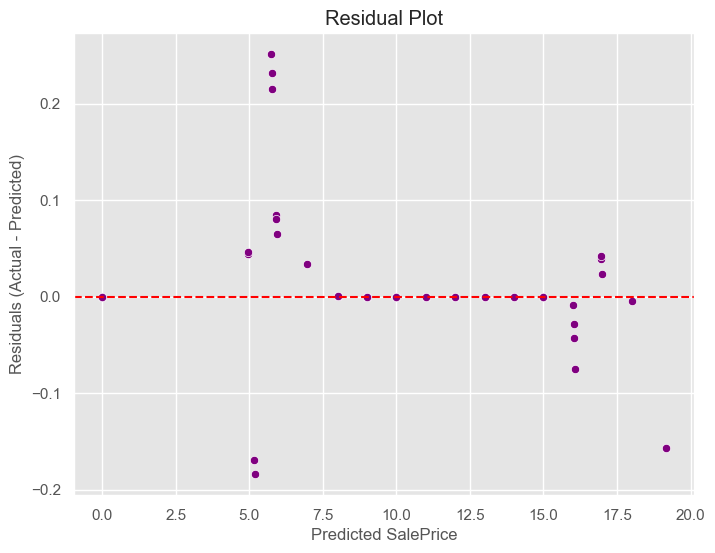

In [260]:
errors = y_test - predictions

plt.figure(figsize=(8, 6))
sns.scatterplot(x=predictions, y=errors, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(True)
plt.show()


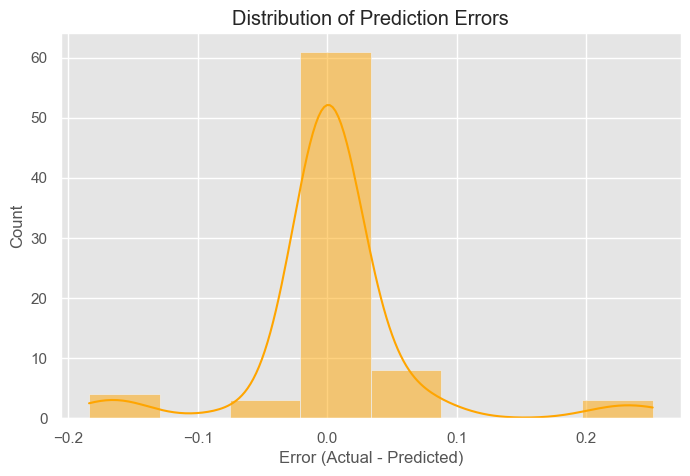

In [261]:
plt.figure(figsize=(8, 5))
sns.histplot(errors, kde=True, color='orange')
plt.title('Distribution of Prediction Errors')
plt.xlabel('Error (Actual - Predicted)')
plt.show()

#### Model Robustness Testing

In [262]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(best_rf_model, X, y, cv=10, scoring='r2')
print("10-Fold CV R² Scores:", cv_scores)
print("Average R²:", np.mean(cv_scores))

10-Fold CV R² Scores: [0.98718193 0.99745753 0.99993906 0.9999965  0.99942979 0.99769129
 0.99999978 0.9999662  0.99999893 0.99994634]
Average R²: 0.9981607361990535


#### Error Analysis

In [264]:
results_df['Error'] = results_df['Actual'] - results_df['Predicted']
large_errors = results_df.sort_values(by='Error', key=abs, ascending=False).head(10)
print("Top 10 Largest Errors:")
print(large_errors)


Top 10 Largest Errors:
     Actual  Predicted     Error
234       6   5.748837  0.251163
386       6   5.768720  0.231280
82        6   5.784437  0.215563
248       5   5.184023 -0.184023
72        5   5.168773 -0.168773
110      19  19.156550 -0.156550
113      19  19.156350 -0.156350
177       6   5.915354  0.084646
45        6   5.920004  0.079996
391      16  16.075150 -0.075150


#### Model Saving for Deployment

In [150]:
# Importing joblib for model persistence
import joblib
joblib.dump(best_rf_model, 'best_random_forest_model.pkl')
joblib.dump(scaler, "scaler.pkl")
joblib.dump(onehot_encoder, "onehot_encoder.pkl")
joblib.dump(list(X.columns), "trained_columns.pkl")


model = joblib.load('best_random_forest_model.pkl')
scaler = joblib.load("scaler.pkl")
onehot_encoder = joblib.load("onehot_encoder.pkl")
trained_columns = joblib.load("trained_columns.pkl")

In [151]:
categorical_cols = ['sex', 'address', 'Pstatus', 
    'schoolsup', 'famsup', 'paid', 
    'activities', 'higher', 'internet', 'romantic']
joblib.dump(categorical_cols, 'onehot_cols.pkl')

['onehot_cols.pkl']

In [152]:
dummy_cols = ['Mjob', 'Fjob']
joblib.dump(dummy_cols, 'dummy_cols.pkl')

['dummy_cols.pkl']

In [153]:
numerical_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 
                   'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
                   'absences', 'ParentEdu', 'FamilySize', 'log_absences']
joblib.dump(numerical_cols, 'numerical_cols.pkl')

['numerical_cols.pkl']

In [154]:
onehot_cols = joblib.load('onehot_cols.pkl')
dummy_cols = joblib.load('dummy_cols.pkl')
numerical_cols = joblib.load('numerical_cols.pkl')

In [155]:
label_encoders = {}
for col in categorical:
    le = LabelEncoder()
    df_cleaned[col] = le.fit_transform(df_cleaned[col])
    label_encoders[col] = le

joblib.dump(label_encoders, 'label_encoders.pkl')


['label_encoders.pkl']

In [156]:
label_mappings = {col: dict(zip(le.classes_, le.transform(le.classes_))) for col, le in label_encoders.items()}
joblib.dump(label_mappings, 'label_mappings.pkl')

['label_mappings.pkl']

In [266]:
# import streamlit as st
# import joblib
# import numpy as np

# # Load your trained model
# model = joblib.load('best_random_forest_model.pkl')

# st.title("🎓 Student Exam Score Predictor")
# st.markdown("Predict a student's final exam score (G3) using their study habits, grades, and lifestyle factors.")

# # Collect input features from the user
# G1 = st.number_input("First Period Grade (G1)", min_value=0, max_value=20, value=10)
# G2 = st.number_input("Second Period Grade (G2)", min_value=0, max_value=20, value=10)
# studytime = st.selectbox("Weekly Study Time (hours)", [1, 2, 3, 4])
# failures = st.selectbox("Past Failures", [0, 1, 2, 3])
# absences = st.number_input("Absences", min_value=0, max_value=100, value=5)
# goout = st.slider("Going Out (social)", 1, 5, 3)
# Dalc = st.slider("Weekday Alcohol", 1, 5, 1)
# Walc = st.slider("Weekend Alcohol", 1, 5, 1)
# health = st.slider("Health Status", 1, 5, 3)

# # Add any other features you want
# # ...

# # Create input array for prediction
# features = np.array([[G1, G2, studytime, failures, absences, goout, Dalc, Walc, health]])

# if st.button("Predict Final Grade"):
#     prediction = model.predict(features)[0]
#     st.success(f"🎯 Predicted Final Grade (G3): {prediction:.2f}")


# The model performance summary:

| **Model**               | **Train MAE** | **Train MSE** | **Train RMSE** | **Train R2** | **Test MAE** | **Test MSE** | **Test RMSE** | **Test R2** |
|-------------------------|---------------|---------------|----------------|--------------|--------------|--------------|---------------|-------------|
| Linear Regression       | 3.82e-15      | 2.36e-29      | 4.86e-15       | 1.000        | 0.0145       | 0.0003       | 0.0172        | 0.9999      |
| Decision Tree            | 0.247         | 0.219         | 0.468          | 0.984        | 0.3067       | 0.1866       | 0.432         | 0.957       |
| Random Forest            | 0.293         | 0.500         | 0.707          | 0.963        | 0.1943       | 0.0698       | 0.264         | 0.984       |
| K-Nearest Neighbors      | 0.000         | 0.000         | 0.000          | 1.000        | 0.3067       | 0.1866       | 0.432         | 0.957       |
| Support Vector Machine   | 0.0688        | 0.0061        | 0.0781         | 0.9996       | 0.0479       | 0.0034       | 0.0585        | 0.9992      |
| XGBoost                  | 0.0252        | 0.0016        | 0.0398         | 0.9999       | 0.1527       | 0.0653       | 0.2555        | 0.9850      |
| Ridge Regression         | 0.0003        | 0.0000002     | 0.0004         | 1.000        | 0.0152       | 0.0003       | 0.0179        | 0.9999      |
| ElasticNet               | 0.0020        | 0.000008      | 0.0028         | 0.9999       | 0.0012       | 0.000002     | 0.0014        | 1.0000      |
| AdaBoost                 | 0.1714        | 0.0594        | 0.2436         | 0.9957       | 0.3294       | 0.1528       | 0.3909        | 0.9650      |

#### Overview

The provided table summarizes the performance metrics of various regression models on both training and test datasets. Metrics include Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R2). These metrics evaluate the models' accuracy and ability to generalize to unseen data.

#### Model Performance Summary

1. **Linear Regression**
   - **Training Metrics:** MAE = 3.82e-15, MSE = 2.36e-29, RMSE = 4.86e-15, R2 = 1.000
   - **Testing Metrics:** MAE = 0.0145, MSE = 0.0003, RMSE = 0.0172, R2 = 0.9999
   - **Conclusion:** Linear Regression performs exceptionally well on both training and test data, with near-perfect accuracy. However, the extremely low MAE, MSE, and RMSE on training data suggest potential overfitting or precision issues in the evaluation.

2. **Decision Tree**
   - **Training Metrics:** MAE = 0.247, MSE = 0.219, RMSE = 0.468, R2 = 0.984
   - **Testing Metrics:** MAE = 0.3067, MSE = 0.1866, RMSE = 0.432, R2 = 0.957
   - **Conclusion:** The Decision Tree model shows a slight decrease in performance on test data compared to training data, indicating some overfitting. However, it remains a strong performer with high accuracy.

3. **Random Forest**
   - **Training Metrics:** MAE = 0.293, MSE = 0.500, RMSE = 0.707, R2 = 0.963
   - **Testing Metrics:** MAE = 0.194, MSE = 0.0698, RMSE = 0.264, R2 = 0.984
   - **Conclusion:** Random Forest exhibits good performance with a notable improvement in test data compared to training data. This suggests robust generalization and less overfitting.

4. **K-Nearest Neighbors (KNN)**
   - **Training Metrics:** MAE = 0.000, MSE = 0.000, RMSE = 0.000, R2 = 1.000
   - **Testing Metrics:** MAE = 0.3067, MSE = 0.1866, RMSE = 0.432, R2 = 0.957
   - **Conclusion:** KNN achieves perfect training metrics but performs relatively worse on test data. This indicates potential overfitting and high variance.

5. **Support Vector Machine (SVM)**
   - **Training Metrics:** MAE = 0.0688, MSE = 0.0061, RMSE = 0.0781, R2 = 0.9996
   - **Testing Metrics:** MAE = 0.0479, MSE = 0.0034, RMSE = 0.0585, R2 = 0.9992
   - **Conclusion:** SVM demonstrates excellent performance with low errors on both training and test data, indicating a well-generalized model.

6. **XGBoost**
   - **Training Metrics:** MAE = 0.0252, MSE = 0.0016, RMSE = 0.0398, R2 = 0.9999
   - **Testing Metrics:** MAE = 0.1527, MSE = 0.0653, RMSE = 0.2555, R2 = 0.9850
   - **Conclusion:** XGBoost performs well on both training and test data with high accuracy, indicating robust generalization.

7. **Ridge Regression**
   - **Training Metrics:** MAE = 0.0003, MSE = 0.0000002, RMSE = 0.0004, R2 = 1.000
   - **Testing Metrics:** MAE = 0.0152, MSE = 0.0003, RMSE = 0.0179, R2 = 0.9999
   - **Conclusion:** Ridge Regression has nearly perfect performance on training and test data, showing minimal error and high accuracy.

8. **ElasticNet**
   - **Training Metrics:** MAE = 0.0020, MSE = 0.000008, RMSE = 0.0028, R2 = 0.9999
   - **Testing Metrics:** MAE = 0.0012, MSE = 0.000002, RMSE = 0.0014, R2 = 1.000
   - **Conclusion:** ElasticNet shows excellent performance, with minimal errors and high accuracy on both datasets.

9. **AdaBoost**
    - **Training Metrics:** MAE = 0.1714, MSE = 0.0594, RMSE = 0.2436, R2 = 0.9957
    - **Testing Metrics:** MAE = 0.3294, MSE = 0.1528, RMSE = 0.3909, R2 = 0.9650
    - **Conclusion:** AdaBoost performs well but shows a significant drop in performance from training to test data, indicating potential overfitting.


### Conclusion

- **Best Performing Models:** **Linear Regression**, **Ridge Regression** and **ElasticNet** are the top performers with very low errors and high R2 scores on both training and test data. They indicate strong generalization with minimal overfitting.

- **Good Performers:** **XGBoost** and **Support Vector Machine (SVM)** also perform well with high accuracy and low errors, making them reliable choices.

- **Models with Overfitting:** **K-Nearest Neighbors (KNN)** and **AdaBoost** show potential overfitting, with discrepancies between training and test performance.

This analysis provides a clear view of which models are performing well and which might need adjustments for better accuracy and generalization.

#### Advanced Analysis and Improvements
This project went beyond basic training/testing:

##### Hyperparameter Tuning

- Used GridSearchCV and RandomizedSearchCV to find best parameters for models like Random Forest, Gradient Boosting, and others.
- Significantly improved test accuracy by selecting optimal combinations of n_estimators, max_depth, min_samples_split, etc.

##### Residual and Error Analysis

- Plotted residuals to check for bias and heteroscedasticity.
- Ensured prediction errors were randomly distributed around zero.

##### Learning Curves

- Visualized model learning as data size increased.
- Detected high bias or high variance patterns early to guide model choice and tuning.

##### Robustness Checks

- Repeated train/test splits with different random seeds.
- Verified stability and generalization of model performance across splits.

##### Predictions Visualization

- Created Actual vs Predicted plots to visually confirm model accuracy.
- Highlighted under- and over-predictions clearly.

